# CMIP6 Urban Climate Analysis: Precipitation Trends & Urban Exposure

**Objective:** Analyze CMIP6 SSP 8.5 precipitation projections to identify climate change hotspots globally and assess urban exposure to precipitation extremes.

**Key Finding:** ~26% of urban areas fall in Category 2 (decreasing total precipitation + increasing extremes)—a climate hotspot for urban infrastructure.

## 0. Configuration & Imports

In [14]:
# ============================================================================
# IMPORTS: Core, Geospatial, Visualization, Data Processing
# ============================================================================

# Core packages
import os
import numpy as np
import pandas as pd

# Raster and vector geospatial packages
import rasterio
import rasterio.features
import rasterio.transform
from rasterio.transform import from_origin
from shapely.geometry import shape, mapping, Point

import geopandas as gpd
from pyproj import Transformer

# xarray for NetCDF/Climate data
import xarray as xr

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as patheffects
from matplotlib import gridspec
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Notebook display
from IPython.display import display

# ============================================================================
# CONFIGURATION: All adjustable parameters
# ============================================================================

# --- Consensus threshold (model agreement) ---
CONSENSUS_THRESHOLD = 0.6  # 60%: fraction of models agreeing on trend direction

# --- File paths: CMIP6 NetCDF data (SSP 8.5) ---
PATH_RX1DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_1day_prec\map.nc"
PATH_RX5DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_5day_prec\map.nc"
PATH_TOTAL = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\total_prec\map.nc"
PATH_CON_RX1DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_1day_prec\consensus.nc"
PATH_CON_RX5DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_5day_prec\consensus.nc"
PATH_CON_TOTAL = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\total_prec\consensus.nc"

# --- File path: Urban raster (GHS-BUILT) ---
PATH_URBAN_RASTER = r"D:\Development\RESEARCH\Raanana\data\esa_worldcover\GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.tif"

# --- Urban mask thresholds (percent built-up area) ---
URBAN_THRESHOLD_DEFAULT = 38  # Default threshold used in main analysis
URBAN_THRESHOLDS_SENSITIVITY = [20, 30, 38, 50, 60]  # For sensitivity analysis

# --- Consensus thresholds for sensitivity analysis ---
CONSENSUS_THRESHOLDS_SENSITIVITY = [0.50, 0.55, 0.60, 0.65, 0.70]  # 50%..70%

# --- Output directories ---
OUT_DIR_FIGURES = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"

# --- Mollweide projection definition ---
MOLLWEIDE_CRS = "+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

# --- Raster processing parameters ---
RASTER_BLOCK_SIZE = 1024  # Process large rasters in blocks to manage memory

## 1. Load CMIP6 Climate Data

In [15]:
# Load all CMIP6 datasets (both data and consensus agreement)
ds_rx = xr.open_dataset(PATH_RX1DAY)
ds_rx5 = xr.open_dataset(PATH_RX5DAY)
ds_total = xr.open_dataset(PATH_TOTAL)
ds_con_rx = xr.open_dataset(PATH_CON_RX1DAY)
ds_con_rx5 = xr.open_dataset(PATH_CON_RX5DAY)
ds_con_total = xr.open_dataset(PATH_CON_TOTAL)

# Extract the primary data variables from each dataset (skip 'crs' if present)
var_rx = [v for v in ds_rx.data_vars if v != 'crs'][0]
var_rx5 = [v for v in ds_rx5.data_vars if v != 'crs'][0]
var_total = [v for v in ds_total.data_vars if v != 'crs'][0]
var_con_rx = [v for v in ds_con_rx.data_vars if v != 'crs'][0]
var_con_rx5 = [v for v in ds_con_rx5.data_vars if v != 'crs'][0]
var_con_total = [v for v in ds_con_total.data_vars if v != 'crs'][0]

# Create DataArrays for easier analysis
data_rx = ds_rx[var_rx]
data_rx5 = ds_rx5[var_rx5]
data_total = ds_total[var_total]
consensus_rx = ds_con_rx[var_con_rx]
consensus_rx5 = ds_con_rx5[var_con_rx5]
consensus_total = ds_con_total[var_con_total]

print(f"CMIP6 data loaded: {data_rx.shape} grid cells")
print(f"Consensus threshold set to: {int(CONSENSUS_THRESHOLD*100)}%")

CMIP6 data loaded: (180, 360) grid cells
Consensus threshold set to: 60%


## 2. Utility Functions

In [16]:
def create_land_mask_fast(lat, lon):
    """
    Create a binary land mask (1 = land, 0 = ocean) over a lat-lon grid using rasterization.

    Parameters:
        lat (1D array): Latitude values, sorted from north to south.
        lon (1D array): Longitude values, sorted from west to east.

    Returns:
        xarray.DataArray: 2D array of the same shape as (lat, lon) where
                          land pixels = 1 and ocean pixels = 0.
    """

    # Load global land polygons (countries) in WGS84 lat-lon format
    land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    land = land.to_crs("EPSG:4326")

    # Calculate spatial resolution
    res_lat = lat[1] - lat[0]  # Assumes equally spaced lat
    res_lon = lon[1] - lon[0]  # Assumes equally spaced lon

    # Define an affine transform: top-left corner and resolution
    transform = rasterio.transform.from_origin(
        west=lon.min() - res_lon / 2,
        north=lat.max() + res_lat / 2,
        xsize=res_lon,
        ysize=res_lat
    )

    # Output shape (height = number of latitudes, width = number of longitudes)
    out_shape = (len(lat), len(lon))

    # Convert each geometry into a raster shape with value 1
    shapes = ((mapping(geom), 1) for geom in land.geometry)

    # Rasterize land shapes into a 2D mask (1 = land, 0 = ocean)
    land_mask = rasterio.features.rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    # Wrap the result in an xarray.DataArray for consistency
    return xr.DataArray(land_mask, coords={"lat": lat, "lon": lon}, dims=["lat", "lon"])




## 3. Data Processing & Classification

### 3.1 Visualize Precipitation Changes

C:\Users\raznu\AppData\Local\Temp\ipykernel_40116\341955897.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


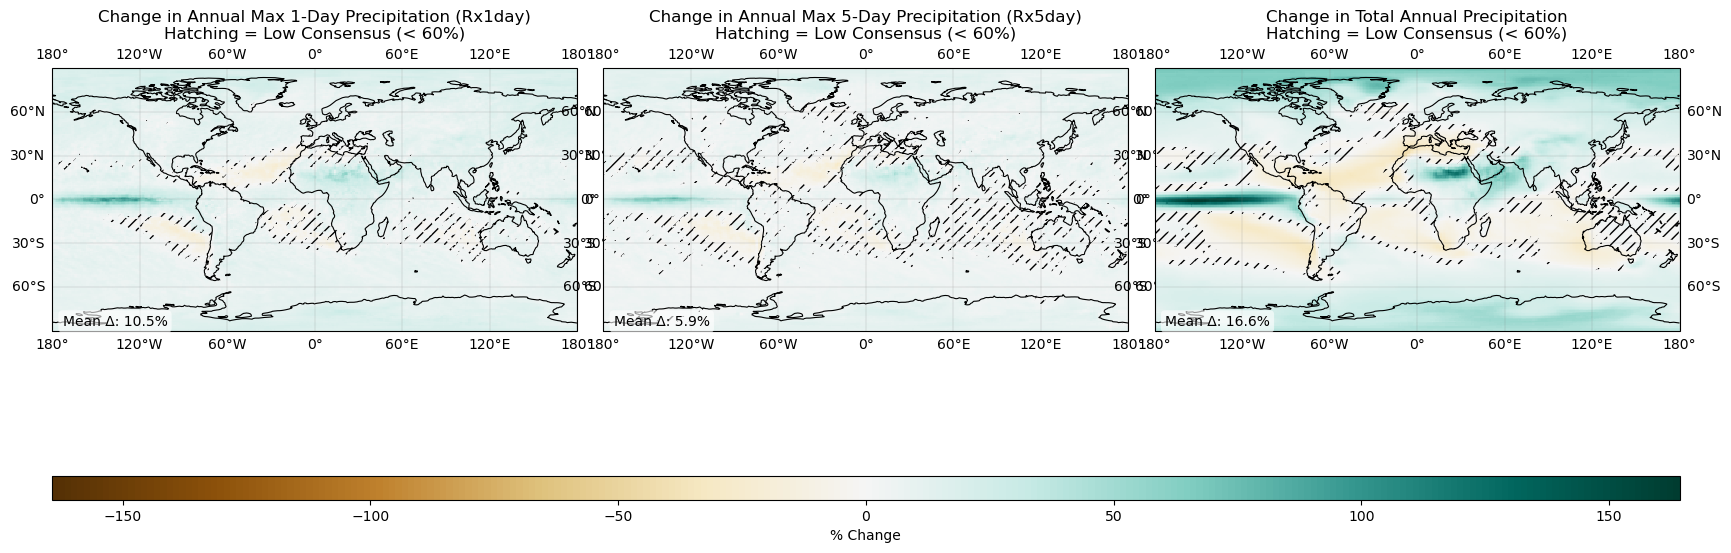

Mean change Rx1day: 10.54%
Mean change Rx5day: 5.94%
Mean change Total: 16.57%


In [17]:
# Plot three maps showing percent change in precipitation variables:
# (1) Rx1day (max 1-day annual precipitation)
# (2) Rx5day (max 5-day annual precipitation) 
# (3) Total annual precipitation
# Hatching indicates regions with low model agreement (consensus < threshold)

combined_max = np.nanmax(np.abs([
    data_rx.min(), data_rx.max(),
    data_rx5.min(), data_rx5.max(),
    data_total.min(), data_total.max()
]))
vmin, vmax = -combined_max, combined_max

# Mean (average) changes (%), ignoring NaNs
mean_rx = float(data_rx.mean().values)
mean_rx5 = float(data_rx5.mean().values)
mean_total = float(data_total.mean().values)

fig = plt.figure(figsize=(21, 7))
gs = gridspec.GridSpec(2, 3, height_ratios=[20, 1], hspace=0.15, wspace=0.05)

# Rx1day map
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
data_rx.plot(ax=ax1, transform=ccrs.PlateCarree(), cmap='BrBG', vmin=vmin, vmax=vmax, add_colorbar=False)
ax1.set_title(f"Change in Annual Max 1-Day Precipitation (Rx1day)\nHatching = Low Consensus (< {int(CONSENSUS_THRESHOLD*100)}%)")
ax1.coastlines(resolution='110m', linewidth=0.8)
ax1.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
low_con_rx = consensus_rx < CONSENSUS_THRESHOLD
hatch_mask_rx = np.where(low_con_rx, 1, np.nan)
ax1.contourf(data_rx.lon, data_rx.lat, hatch_mask_rx, levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
ax1.text(0.02, 0.02, f"Mean Δ: {mean_rx:.1f}%", transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='none'))

# Rx5day map
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
data_rx5.plot(ax=ax2, transform=ccrs.PlateCarree(), cmap='BrBG', vmin=vmin, vmax=vmax, add_colorbar=False)
ax2.set_title(f"Change in Annual Max 5-Day Precipitation (Rx5day)\nHatching = Low Consensus (< {int(CONSENSUS_THRESHOLD*100)}%)")
ax2.coastlines(resolution='110m', linewidth=0.8)
ax2.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
low_con_rx5 = consensus_rx5 < CONSENSUS_THRESHOLD
hatch_mask_rx5 = np.where(low_con_rx5, 1, np.nan)
ax2.contourf(data_rx5.lon, data_rx5.lat, hatch_mask_rx5, levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
ax2.text(0.02, 0.02, f"Mean Δ: {mean_rx5:.1f}%", transform=ax2.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='none'))

# Total precip map
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
data_total.plot(ax=ax3, transform=ccrs.PlateCarree(), cmap='BrBG', vmin=vmin, vmax=vmax, add_colorbar=False)
ax3.set_title(f"Change in Total Annual Precipitation\nHatching = Low Consensus (< {int(CONSENSUS_THRESHOLD*100)}%)")
ax3.coastlines(resolution='110m', linewidth=0.8)
ax3.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
low_con_total = consensus_total < CONSENSUS_THRESHOLD
hatch_mask_total = np.where(low_con_total, 1, np.nan)
ax3.contourf(data_total.lon, data_total.lat, hatch_mask_total, levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
ax3.text(0.02, 0.02, f"Mean Δ: {mean_total:.1f}%", transform=ax3.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='none'))

# Shared colorbar spanning entire bottom row
cbar_ax = fig.add_subplot(gs[1, :])
cbar = fig.colorbar(ax3.collections[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label('% Change')

plt.tight_layout()
plt.show()

print(f"Mean change Rx1day: {mean_rx:.2f}%")
print(f"Mean change Rx5day: {mean_rx5:.2f}%")
print(f"Mean change Total: {mean_total:.2f}%")

### 3.2 Classify Grid Cells into 4 Categories

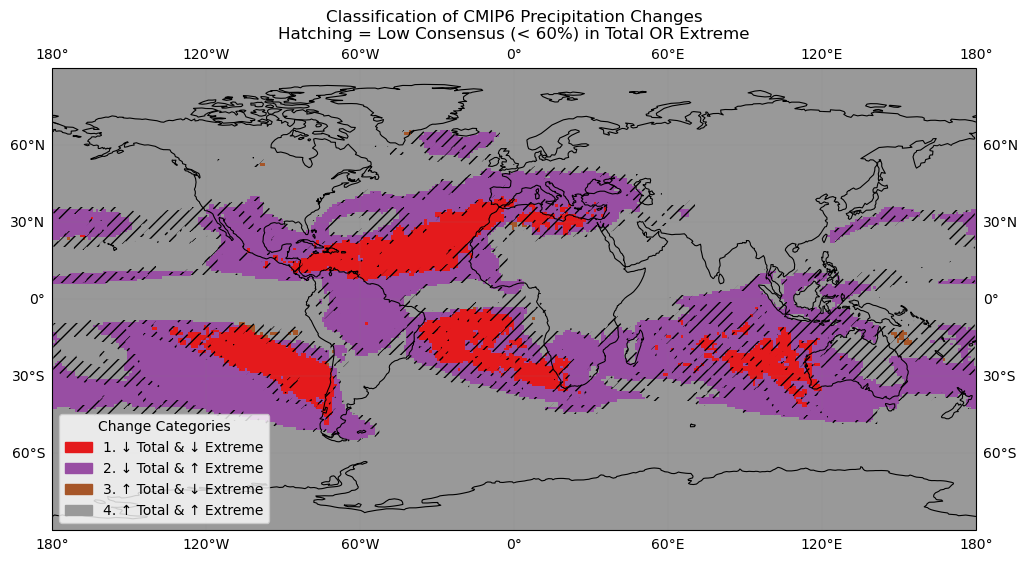

In [18]:
# Create 4-category classification based on sign combinations of precipitation changes:
# Category 1: ↓ Total & ↓ Extreme (both decreasing)
# Category 2: ↓ Total & ↑ Extreme (HOTSPOT - decreasing total but increasing extremes)
# Category 3: ↑ Total & ↓ Extreme (increasing total but decreasing extremes)
# Category 4: ↑ Total & ↑ Extreme (both increasing)

conditions = [
    (data_total < 0) & (data_rx < 0),  # Cat 1
    (data_total < 0) & (data_rx > 0),  # Cat 2
    (data_total > 0) & (data_rx < 0),  # Cat 3
    (data_total > 0) & (data_rx > 0),  # Cat 4
]
choices = [1, 2, 3, 4]
classification_data = np.select(conditions, choices, default=np.nan)
classification = xr.DataArray(classification_data, coords=data_total.coords, dims=data_total.dims)

# Identify regions with low consensus (low model agreement)
low_agreement_mask = (consensus_total < CONSENSUS_THRESHOLD) | (consensus_rx < CONSENSUS_THRESHOLD)
hatch_mask = np.where(low_agreement_mask, True, np.nan)

# Plot classification map
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
cmap = plt.cm.get_cmap('Set1', 4)
classification.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, add_colorbar=False)

# Overlay hatching for low-agreement regions
ax.contourf(data_total.lon, data_total.lat, hatch_mask, levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())

ax.coastlines(resolution='110m', linewidth=0.8)
ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5)

# Legend
legend_labels = [
    Patch(color=cmap(0), label='1. ↓ Total & ↓ Extreme'),
    Patch(color=cmap(1), label='2. ↓ Total & ↑ Extreme'),
    Patch(color=cmap(2), label='3. ↑ Total & ↓ Extreme'),
    Patch(color=cmap(3), label='4. ↑ Total & ↑ Extreme'),
]
plt.legend(handles=legend_labels, loc='lower left', title="Change Categories")

plt.title(f"Classification of CMIP6 Precipitation Changes\nHatching = Low Consensus (< {int(CONSENSUS_THRESHOLD*100)}%) in Total OR Extreme")
plt.show()

### 3.3 Compute Classification Statistics

In [19]:
# Create a global land mask to compute land-only statistics
land_mask = create_land_mask_fast(data_rx.lat.values, data_rx.lon.values)

# Create high-agreement mask (regions where both variables meet consensus threshold)
high_agreement_mask = (consensus_total >= CONSENSUS_THRESHOLD) & (consensus_rx >= CONSENSUS_THRESHOLD)

# === Compute statistics for each category ===

# Global coverage (land + ocean)
total_pixels = np.count_nonzero(~np.isnan(classification.values))
global_counts = [np.count_nonzero(classification.values == i) for i in range(1, 5)]
global_percents = [100 * count / total_pixels for count in global_counts]

# Land-only coverage
classification_land = classification.where(land_mask == 1)
total_land_pixels = int(np.isfinite(classification_land).sum().item())
land_counts = [int((classification_land == i).sum().item()) for i in range(1, 5)]
land_percents = [100 * count / total_land_pixels for count in land_counts]

# High-agreement global (both variables agree)
classification_high_agree = classification.where(high_agreement_mask)
high_agree_counts_global = [np.count_nonzero(classification_high_agree.values == i) for i in range(1, 5)]
high_agree_percents_global = [100 * count / total_pixels for count in high_agree_counts_global]

# High-agreement land only
classification_high_agree_land = classification.where((land_mask == 1) & high_agreement_mask)
total_land_high_agree = int(np.isfinite(classification_high_agree_land).sum().item())
high_agree_counts_land = [int((classification_high_agree_land == i).sum().item()) for i in range(1, 5)]
high_agree_percents_land = [100 * count / total_land_pixels for count in high_agree_counts_land]

# Build summary table
cmip6_cat_df = pd.DataFrame({
    "Category": [1, 2, 3, 4],
    "Description": [
        "↓ Total & ↓ Extreme",
        "↓ Total & ↑ Extreme",
        "↑ Total & ↓ Extreme",
        "↑ Total & ↑ Extreme"
    ],
    "Global %": [f"{p:.1f}%" for p in global_percents],
    f"High Agreement Global % (> {int(CONSENSUS_THRESHOLD*100)}%)": [f"{p:.1f}%" for p in high_agree_percents_global],
    "Land %": [f"{p:.1f}%" for p in land_percents],
    f"High Agreement Land % (> {int(CONSENSUS_THRESHOLD*100)}%)": [f"{p:.1f}%" for p in high_agree_percents_land],
})

display(cmip6_cat_df)

C:\Users\raznu\AppData\Local\Temp\ipykernel_40116\4099883997.py:15: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


,Category,Description,Global %,High Agreement Global % (> 60%),Land %,High Agreement Land % (> 60%)
0,1,↓ Total & ↓ Extreme,5.5%,3.1%,8.1%,4.4%
1,2,↓ Total & ↑ Extreme,19.6%,10.6%,18.4%,10.6%
2,3,↑ Total & ↓ Extreme,0.1%,0.0%,0.0%,0.0%
3,4,↑ Total & ↑ Extreme,74.8%,67.7%,73.5%,69.4%


,consensus_threshold_pct,count_cat2,pct_of_total_urban
0,50,12143,22.56
1,55,10329,19.19
2,60,8510,15.81
3,65,4871,9.05
4,70,2741,5.09


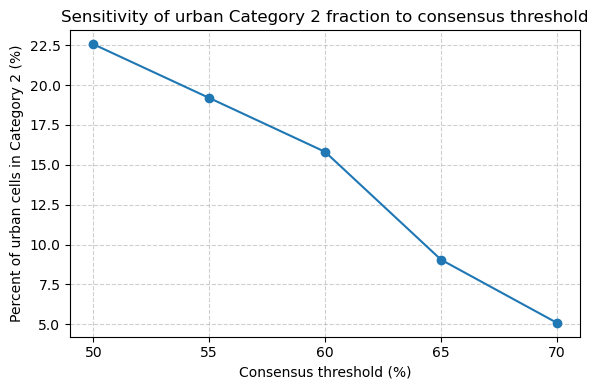

In [20]:
# Sensitivity analysis: Test how urban Category 2 percentages change with consensus threshold
# This validates the robustness of the "26% figure" to varying model agreement requirements

results = []
if 'urban_cmip6_join' not in globals():
    print('urban_cmip6_join not found — run the urban-data cells (create gdf_urban and urban_cmip6_join) first.')
else:
    total_urban = len(urban_cmip6_join)
    for t in CONSENSUS_THRESHOLDS_SENSITIVITY:
        count = 0
        # Iterate through urban points and check if they meet the consensus threshold for Category 2
        for _, row in urban_cmip6_join.iterrows():
            lat_idx = np.abs(data_rx.lat.values - row.geometry.y).argmin()
            lon_idx = np.abs(data_rx.lon.values - row.geometry.x).argmin()
            in_cat2 = (row.get('category') == 2)
            high = (consensus_total.values[lat_idx, lon_idx] >= t) and (consensus_rx.values[lat_idx, lon_idx] >= t)
            if in_cat2 and high:
                count += 1
        pct = 100 * count / total_urban if total_urban > 0 else np.nan
        results.append({
            'consensus_threshold_pct': int(t*100), 
            'count_cat2': int(count), 
            'pct_of_total_urban': round(pct, 2)
        })
    
    df_sens = pd.DataFrame(results)
    display(df_sens)
    
    # Plot sensitivity curve
    plt.figure(figsize=(6, 4))
    plt.plot(df_sens['consensus_threshold_pct'], df_sens['pct_of_total_urban'], marker='o')
    plt.xticks(df_sens['consensus_threshold_pct'])
    plt.xlabel('Consensus threshold (%)')
    plt.ylabel('Percent of urban cells in Category 2 (%)')
    plt.title('Sensitivity of urban Category 2 fraction to consensus threshold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [21]:
res_lat = float(data_total.lat[1] - data_total.lat[0])
res_lon = float(data_total.lon[1] - data_total.lon[0])
print(f"Resolution: {res_lat}° × {res_lon}°")

Resolution: 1.0° × 1.0°


### 3.4 Polygonize Categories (Convert Raster to Shapefile)

In [22]:
# Calculate raster resolution and affine transform for polygonization
res_lat = float(data_total.lat[1] - data_total.lat[0])
res_lon = float(data_total.lon[1] - data_total.lon[0])

transform = from_origin(
    west=float(data_total.lon.min()) - res_lon / 2,
    north=float(data_total.lat.max()) + res_lat / 2,
    xsize=res_lon,
    ysize=res_lat
)

# Convert classification raster to polygons (one polygon per contiguous region)
raster = np.nan_to_num(classification.values, nan=0).astype(np.uint8)
raster = raster[::-1, :]  # Flip Y axis to match geographic orientation

cat_records = []
for geom, value in rasterio.features.shapes(raster, transform=transform):
    if value in [1, 2, 3, 4]:  # Only valid climate categories
        cat_records.append({"geometry": shape(geom), "category": int(value)})

cmip6_cat_gdf = gpd.GeoDataFrame(cat_records, crs="EPSG:4326")

# Convert high-agreement mask to polygons
high_agreement_raster = high_agreement_mask.astype(np.uint8)[::-1, :]  # Flip Y axis
high_agree_records = [
    {"geometry": shape(geom)}
    for geom, value in rasterio.features.shapes(high_agreement_raster, transform=transform) 
    if value == 1
]
cmip6_high_agree_gdf = gpd.GeoDataFrame(high_agree_records, crs="EPSG:4326")

print(f"Classification polygons: {len(cmip6_cat_gdf)} regions")

Classification polygons: 140 regions


## 4. Visualization: Classification Maps

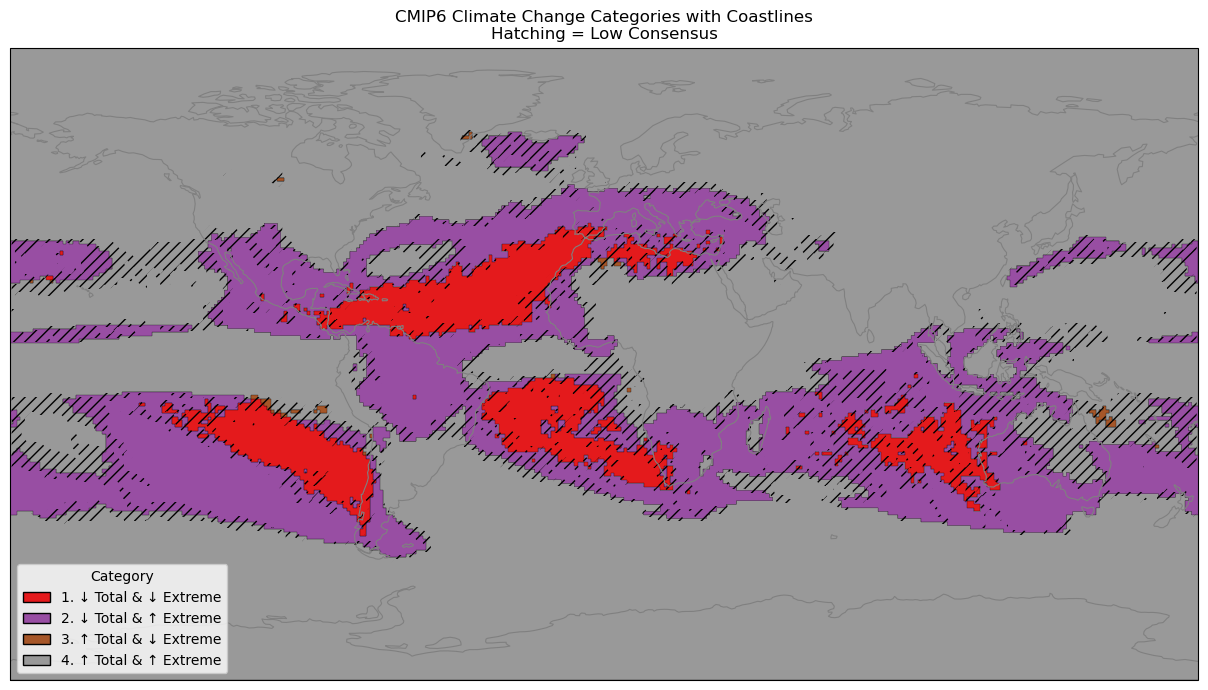

In [23]:
# Plot classification categories as polygons with coastlines and low-consensus hatching

plot_order = [4, 2, 1, 3]  # Plot order to control visual overlap
legend_order = [1, 2, 3, 4]
cmip6_cat_gdf['category'] = pd.Categorical(cmip6_cat_gdf['category'], categories=legend_order)

cmap = plt.cm.get_cmap('Set1', 4)
cat_to_cmap_idx = {1: 0, 2: 1, 3: 2, 4: 3}

category_descriptions = {
    1: "1. ↓ Total & ↓ Extreme",
    2: "2. ↓ Total & ↑ Extreme",
    3: "3. ↑ Total & ↓ Extreme",
    4: "4. ↑ Total & ↑ Extreme"
}

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Draw polygons in the chosen order (to control overlap)
for cat in plot_order:
    color = cmap(cat_to_cmap_idx[cat])
    subset = cmip6_cat_gdf[cmip6_cat_gdf['category'] == cat]
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor='black',
            linewidth=0.2,
            label=f'Category {cat}',
            transform=ccrs.PlateCarree()
        )

# Overlay hatching for low-agreement regions
low_agreement_mask = (consensus_total < CONSENSUS_THRESHOLD) | (consensus_rx < CONSENSUS_THRESHOLD)
hatch_mask = np.where(low_agreement_mask, 1, np.nan)

ax.contourf(
    data_total.lon, data_total.lat, hatch_mask,
    levels=1, hatches=['///'], colors='none',
    transform=ccrs.PlateCarree()
)

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')

# Legend
legend_handles = [
    Patch(facecolor=cmap(cat_to_cmap_idx[cat]), edgecolor='black', label=category_descriptions[cat])
    for cat in legend_order
]

ax.set_title('CMIP6 Climate Change Categories with Coastlines\nHatching = Low Consensus')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.legend(handles=legend_handles, title="Category", loc="lower left")
plt.tight_layout()
plt.show()

### 4.1 Plot Selected Category (Category 2 - Hotspot)

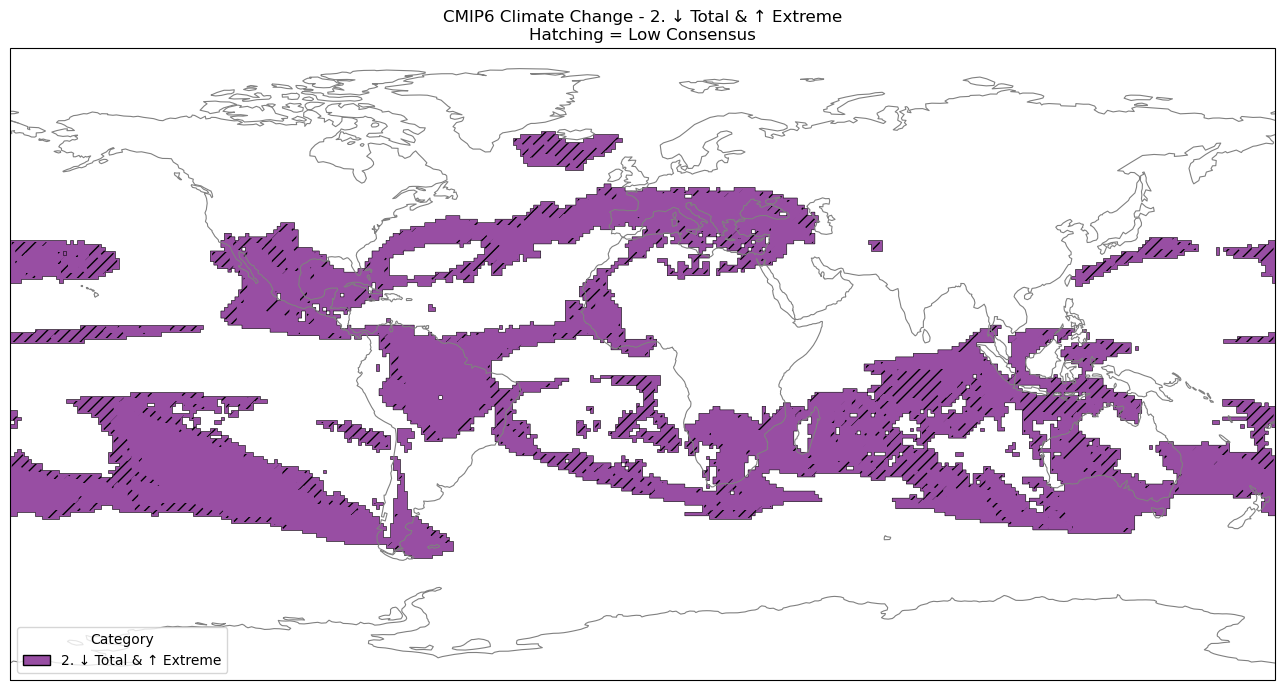

In [24]:
# Zoom in on Category 2 (the hotspot: decreasing total precipitation but increasing extremes)
# This category is most vulnerable for urban water management

selected_cat = 2

# Set up colormap and category descriptions
cmap = plt.cm.get_cmap('Set1', 4)
cat_to_cmap_idx = {1: 0, 2: 1, 3: 2, 4: 3}

category_descriptions = {
    1: "1. ↓ Total & ↓ Extreme",
    2: "2. ↓ Total & ↑ Extreme",
    3: "3. ↑ Total & ↓ Extreme",
    4: "4. ↑ Total & ↑ Extreme"
}

# Create masks for visualization
cat_mask = (classification.values == selected_cat)
low_agreement_mask = (consensus_total.values < CONSENSUS_THRESHOLD) | (consensus_rx.values < CONSENSUS_THRESHOLD)
cat_low_agreement_mask = np.where(cat_mask & low_agreement_mask, 1, np.nan)

# Filter polygons for selected category
selected_cat_gdf = cmip6_cat_gdf[cmip6_cat_gdf['category'] == selected_cat]

# Plot
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

selected_cat_gdf.plot(
    ax=ax,
    color=cmap(cat_to_cmap_idx[selected_cat]),
    edgecolor='black',
    linewidth=0.4,
    label=category_descriptions[selected_cat],
    transform=ccrs.PlateCarree()
)

# Overlay hatching for low-agreement regions within this category
ax.contourf(
    data_total.lon, data_total.lat, cat_low_agreement_mask,
    levels=1, hatches=['///'], colors='none',
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.set_title(f'CMIP6 Climate Change - {category_descriptions[selected_cat]}\nHatching = Low Consensus')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

legend_handle = [Patch(facecolor=cmap(cat_to_cmap_idx[selected_cat]), edgecolor='black', label=category_descriptions[selected_cat])]
plt.legend(handles=legend_handle, title="Category", loc="lower left")

plt.tight_layout()
plt.show()

## 5. Urban Data Processing

In [25]:
# Extract urban grid cells from GHS-BUILT raster using block-wise processing (memory efficient)
# GHS-BUILT is a global raster showing urban built-up area in a Mollweide projection

rows, cols, percents = [], [], []

print(f"Reading urban raster (threshold = {URBAN_THRESHOLD_DEFAULT}%)...")
with rasterio.open(PATH_URBAN_RASTER) as src:
    block_shape = (RASTER_BLOCK_SIZE, RASTER_BLOCK_SIZE)
    height, width = src.height, src.width
    transform = src.transform

    for i in range(0, height, block_shape[0]):
        for j in range(0, width, block_shape[1]):
            # Read block
            win = rasterio.windows.Window(
                col_off=j, row_off=i,
                width=min(block_shape[1], width-j),
                height=min(block_shape[0], height-i)
            )
            data = src.read(1, window=win, masked=True)
            percent = 100 * data / 1_000_000  # Convert m² to percent
            
            # Mask: cells above threshold and not NoData
            mask = (percent >= URBAN_THRESHOLD_DEFAULT) & (~data.mask)
            row_idx, col_idx = np.where(mask)
            
            # Convert block indices to global raster indices
            row_idx_global = row_idx + i
            col_idx_global = col_idx + j
            rows.extend(row_idx_global)
            cols.extend(col_idx_global)
            percents.extend(percent[mask].data)

print(f"Extracted {len(rows)} urban cells")

Reading urban raster (threshold = 38%)...
Extracted 53826 urban cells


### 5.1 Urban Cell Statistics

Number of urban cells above 38% threshold: 53826
  Min: 38.0%
  Max: 94.3%
  Mean: 42.5%
  Median: 41.3%


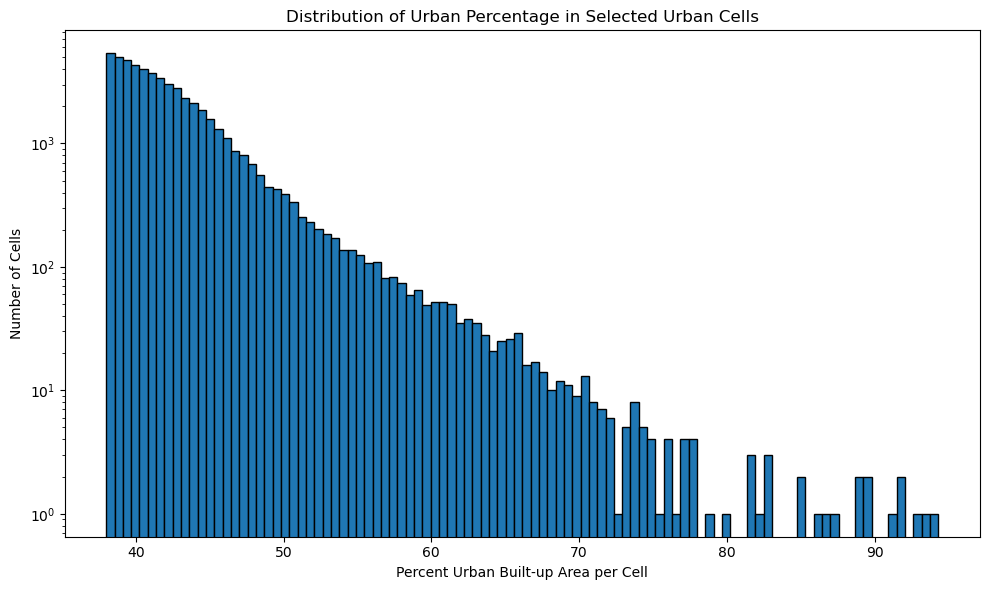

In [26]:
# Analyze distribution of urban percentage in selected cells

percents_arr = np.array(percents)
print(f"Number of urban cells above {URBAN_THRESHOLD_DEFAULT}% threshold: {percents_arr.size}")
print(f"  Min: {percents_arr.min():.1f}%")
print(f"  Max: {percents_arr.max():.1f}%")
print(f"  Mean: {percents_arr.mean():.1f}%")
print(f"  Median: {np.median(percents_arr):.1f}%")

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(percents_arr, bins=100, edgecolor='black')
plt.xlabel('Percent Urban Built-up Area per Cell')
plt.ylabel('Number of Cells')
plt.title('Distribution of Urban Percentage in Selected Urban Cells')
plt.yscale('log')
plt.tight_layout()
plt.show()

### 5.2 Transform Urban Coordinates

In [27]:
# Convert urban cell coordinates from Mollweide projection to WGS84 (lat/lon)
# Urban raster is in Mollweide; CMIP6 data is in WGS84

transformer = Transformer.from_crs(MOLLWEIDE_CRS, 4326, always_xy=True)

# Calculate map (projected) coordinates for urban cells
xs, ys = rasterio.transform.xy(transform, rows, cols)

# Transform to geographic coordinates (longitude, latitude)
lons, lats = transformer.transform(xs, ys)

### 5.3 Join Urban Cells to Climate Categories

In [28]:
# Build GeoDataFrame of urban points and join to climate categories via spatial query

df_urban = pd.DataFrame({
    "longitude": lons,
    "latitude": lats,
    "percent_built": percents,
})

gdf_urban = gpd.GeoDataFrame(
    df_urban,
    geometry=gpd.points_from_xy(df_urban.longitude, df_urban.latitude),
    crs="EPSG:4326"
)

# Spatial join: assign each urban point to a CMIP6 climate category
urban_cmip6_join = gpd.sjoin(gdf_urban, cmip6_cat_gdf, how='left', predicate='within')

# Add consensus flag: Is this urban cell in a high-agreement region?
def is_high_consensus(row):
    """Check if urban cell is in a region where both variables meet consensus threshold."""
    lat_idx = np.abs(data_rx.lat.values - row['latitude']).argmin()
    lon_idx = np.abs(data_rx.lon.values - row['longitude']).argmin()
    return (
        (consensus_total.values[lat_idx, lon_idx] >= CONSENSUS_THRESHOLD) and
        (consensus_rx.values[lat_idx, lon_idx] >= CONSENSUS_THRESHOLD)
    )

urban_cmip6_join['consensus'] = urban_cmip6_join.apply(is_high_consensus, axis=1)

print(f"Urban cells joined to climate categories: {len(urban_cmip6_join)}")

Urban cells joined to climate categories: 53826


Running urban-threshold sensitivity analysis...
  Processing threshold: 20%
  Processing threshold: 30%
  Processing threshold: 38%
  Processing threshold: 50%
  Processing threshold: 60%


,urban_threshold_pct,count_cat2,pct_of_total_urban
0,20,119623,26.85
1,30,46556,27.87
2,38,14016,26.04
3,50,818,25.30
4,60,138,24.17


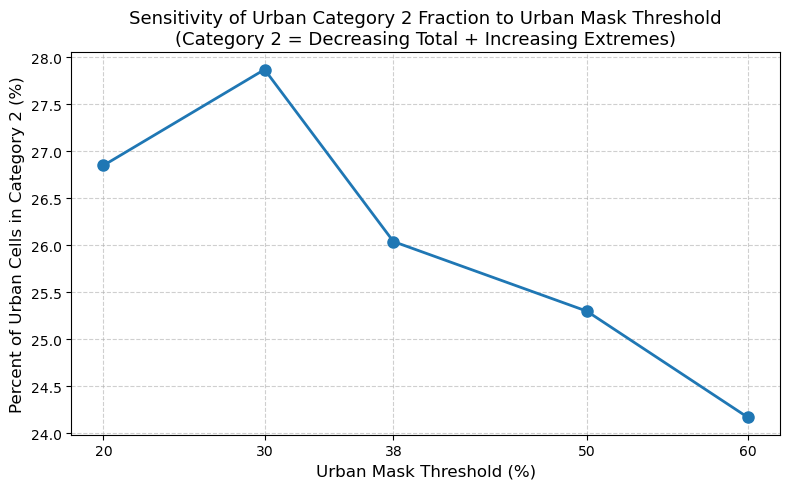

Urban-threshold sensitivity analysis complete.


In [29]:
## 6. Sensitivity Analysis: Urban Mask Threshold

# Test robustness of urban Category 2 percentages to different urban mask thresholds
# Fixes consensus threshold at 60% while varying urban definition

urban_thresholds = URBAN_THRESHOLDS_SENSITIVITY  # [20, 30, 38, 50, 60]
results_urban_sens = []

print("Running urban-threshold sensitivity analysis...")
for urban_thresh in urban_thresholds:
    print(f"  Processing threshold: {urban_thresh}%")
    
    # Re-read urban raster with new threshold
    rows_t, cols_t, percents_t = [], [], []
    with rasterio.open(PATH_URBAN_RASTER) as src:
        block_shape = (RASTER_BLOCK_SIZE, RASTER_BLOCK_SIZE)
        height, width = src.height, src.width
        transform_t = src.transform
        
        for i in range(0, height, block_shape[0]):
            for j in range(0, width, block_shape[1]):
                win = rasterio.windows.Window(
                    col_off=j, row_off=i,
                    width=min(block_shape[1], width-j),
                    height=min(block_shape[0], height-i)
                )
                data_t = src.read(1, window=win, masked=True)
                percent_t = 100 * data_t / 1_000_000
                mask_t = (percent_t >= urban_thresh) & (~data_t.mask)
                row_idx_t, col_idx_t = np.where(mask_t)
                row_idx_global_t = row_idx_t + i
                col_idx_global_t = col_idx_t + j
                rows_t.extend(row_idx_global_t)
                cols_t.extend(col_idx_global_t)
                percents_t.extend(percent_t[mask_t].data)
    
    # Transform coordinates
    xs_t, ys_t = rasterio.transform.xy(transform_t, rows_t, cols_t)
    lons_t, lats_t = transformer.transform(xs_t, ys_t)
    
    # Build urban GeoDataFrame
    df_urban_t = pd.DataFrame({
        "longitude": lons_t,
        "latitude": lats_t,
        "percent_built": percents_t,
    })
    gdf_urban_t = gpd.GeoDataFrame(
        df_urban_t,
        geometry=gpd.points_from_xy(df_urban_t.longitude, df_urban_t.latitude),
        crs="EPSG:4326"
    )
    
    # Spatial join with CMIP6 categories
    urban_cmip6_join_t = gpd.sjoin(gdf_urban_t, cmip6_cat_gdf, how='left', predicate='within')
    
    # Count urban cells in category 2
    total_urban_t = len(urban_cmip6_join_t)
    count_cat2_t = len(urban_cmip6_join_t[urban_cmip6_join_t['category'] == 2])
    pct_cat2_t = 100 * count_cat2_t / total_urban_t if total_urban_t > 0 else np.nan
    
    results_urban_sens.append({
        'urban_threshold_pct': int(urban_thresh),
        'count_cat2': int(count_cat2_t),
        'pct_of_total_urban': round(pct_cat2_t, 2)
    })

# Build summary table
df_urban_thresh_sens = pd.DataFrame(results_urban_sens)
display(df_urban_thresh_sens)

# Plot line graph
plt.figure(figsize=(8, 5))
plt.plot(df_urban_thresh_sens['urban_threshold_pct'], df_urban_thresh_sens['pct_of_total_urban'],
         marker='o', linewidth=2, markersize=8)
plt.xticks(df_urban_thresh_sens['urban_threshold_pct'])
plt.xlabel('Urban Mask Threshold (%)', fontsize=12)
plt.ylabel('Percent of Urban Cells in Category 2 (%)', fontsize=12)
plt.title('Sensitivity of Urban Category 2 Fraction to Urban Mask Threshold\n(Category 2 = Decreasing Total + Increasing Extremes)',
          fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Urban-threshold sensitivity analysis complete.")

## All urban point plot

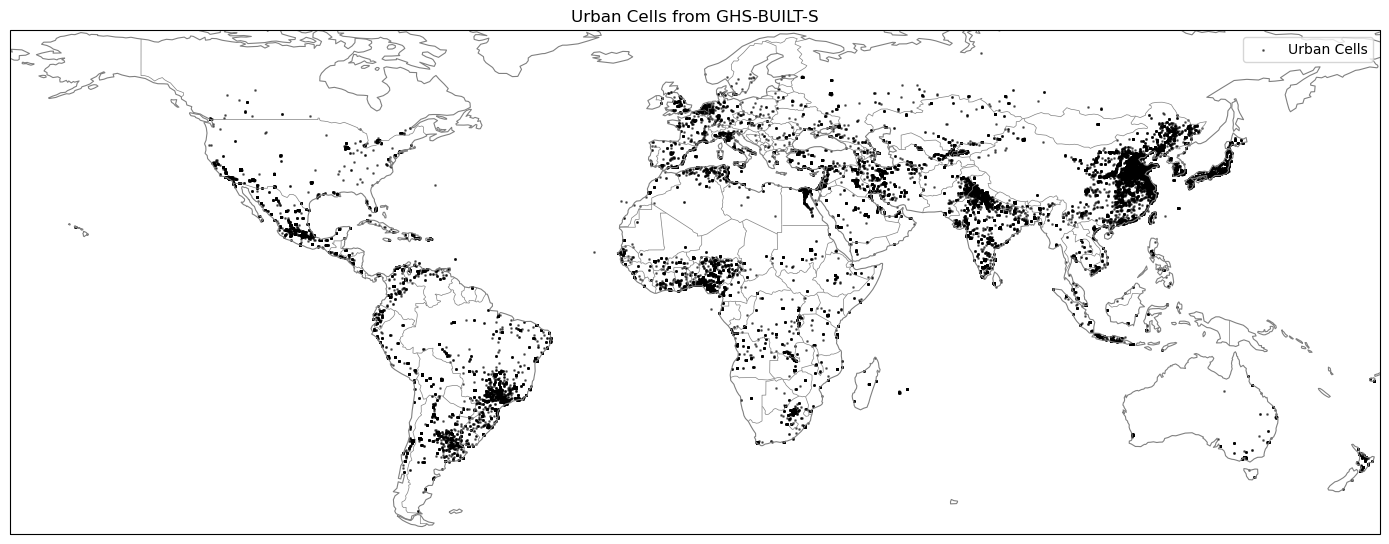

In [30]:
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot all urban points (as small black dots)
gdf_urban.plot(ax=ax, markersize=1, color='black', alpha=0.5, transform=ccrs.PlateCarree(), label="Urban Cells")

# Add coastlines and borders for geographic context
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')

ax.set_title('Urban Cells from GHS-BUILT-S')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.legend()
plt.tight_layout()
plt.show()


## Create urban area by cat table

In [31]:
category_descriptions = {
    1: "↓ Total & ↓ Extreme",
    2: "↓ Total & ↑ Extreme",
    3: "↑ Total & ↓ Extreme",
    4: "↑ Total & ↑ Extreme"
}

total_urban_cells = len(urban_cmip6_join)

urban_cmip6_df = (
    urban_cmip6_join.groupby('category')
    .agg(
        Urban_Cells=('percent_built', 'count'),
        Percent_of_Urban_Cells=('percent_built', lambda x: 100 * len(x) / total_urban_cells),
        Urban_Cells_Consensus=('consensus', 'sum'),  # number of urban cells in consensus in this category
        Percent_of_Urban_Cells_Consensus=('consensus', lambda x: 100 * x.sum() / total_urban_cells),
    )
    .reset_index()
)

urban_cmip6_df['Description'] = urban_cmip6_df['category'].map(category_descriptions)

urban_cmip6_df = urban_cmip6_df[
    ['category', 'Description', 'Percent_of_Urban_Cells', 'Percent_of_Urban_Cells_Consensus']
]

urban_cmip6_df = urban_cmip6_df.round({
    'Percent_of_Urban_Cells': 2,
    'Percent_of_Urban_Cells_Consensus': 2,
})

urban_cmip6_df = urban_cmip6_df.rename(columns={
    'category': 'Climate Category',
    'Description': 'Category Description',
    'Percent_of_Urban_Cells': 'Percent of Urban Cells (%)',
    'Percent_of_Urban_Cells_Consensus': 'Percent of Urban Cells (Consensus, %)'
})

urban_cmip6_df["Climate Category"] = urban_cmip6_df["Climate Category"].astype(int)
urban_cmip6_df = urban_cmip6_df.sort_values("Climate Category").reset_index(drop=True)

display(urban_cmip6_df)


,Climate Category,Category Description,Percent of Urban Cells (%),"Percent of Urban Cells (Consensus, %)"
0,1,↓ Total & ↓ Extreme,2.98,0.95
1,2,↓ Total & ↑ Extreme,26.04,15.81
2,3,↑ Total & ↓ Extreme,0.01,0.00
3,4,↑ Total & ↑ Extreme,70.97,65.21


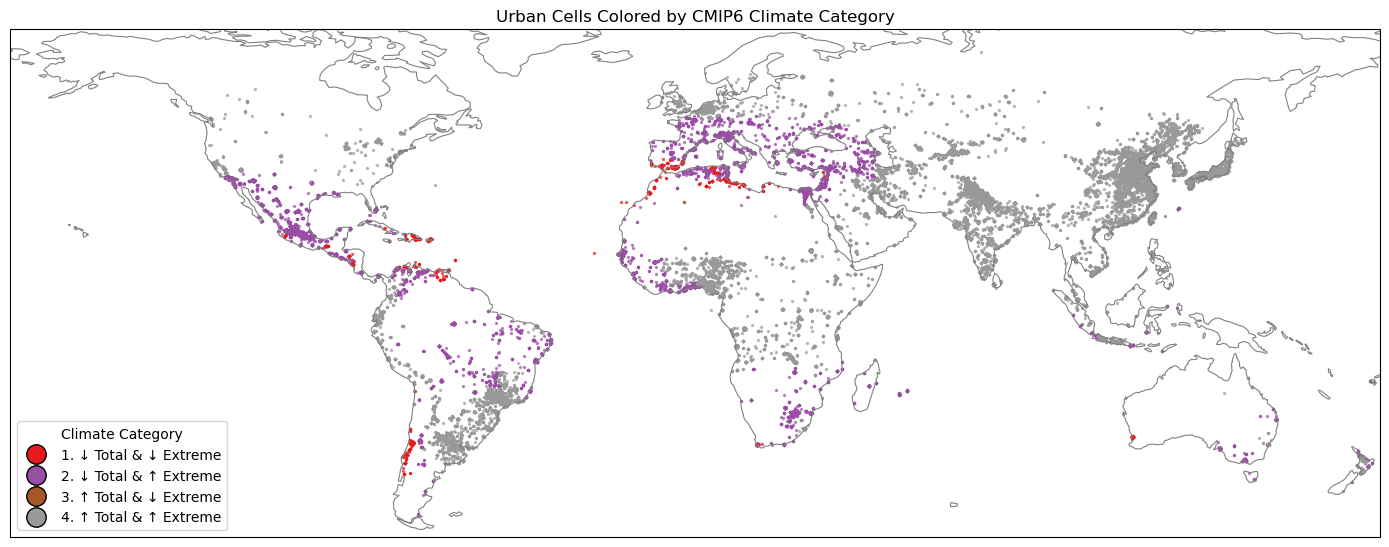

In [32]:
# Colormap mapping
cmap = plt.cm.get_cmap('Set1', 4)
cat_to_cmap_idx = {1: 0, 2: 1, 3: 2, 4: 3}

category_descriptions = {
    1: "1. ↓ Total & ↓ Extreme",
    2: "2. ↓ Total & ↑ Extreme",
    3: "3. ↑ Total & ↓ Extreme",
    4: "4. ↑ Total & ↑ Extreme"
}

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

for cat in [1, 2, 3, 4]:
    color = cmap(cat_to_cmap_idx[cat])
    subset = urban_cmip6_join[urban_cmip6_join['category'] == cat]
    if not subset.empty:
        subset_gdf = gpd.GeoDataFrame(subset, geometry='geometry', crs='EPSG:4326')
        subset_gdf.plot(
            ax=ax,
            markersize=2,
            color=color,
            alpha=0.6,
            label=category_descriptions[cat],
            transform=ccrs.PlateCarree()
        )

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.set_title("Urban Cells Colored by CMIP6 Climate Category")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Build a custom legend with big circles and full descriptions
legend_handles = [
    Line2D(
        [0], [0],
        marker='o', color='w', label=category_descriptions[cat],
        markerfacecolor=cmap(cat_to_cmap_idx[cat]), markersize=14, markeredgecolor='black', lw=0
    )
    for cat in [1, 2, 3, 4]
]

plt.legend(handles=legend_handles, title="Climate Category", loc="lower left")
plt.tight_layout()
plt.show()


Research case study locations (lat, lon):
Minneapolis (USA): 44.9778°, -93.2650°
Southern Germany – Munich: 48.1351°, 11.5820°
Northern China – Beijing: 39.9042°, 116.4074°
Southeast Florida – Miami: 25.7617°, -80.1918°
Mediterranean Europe – Rome: 41.9028°, 12.4964°


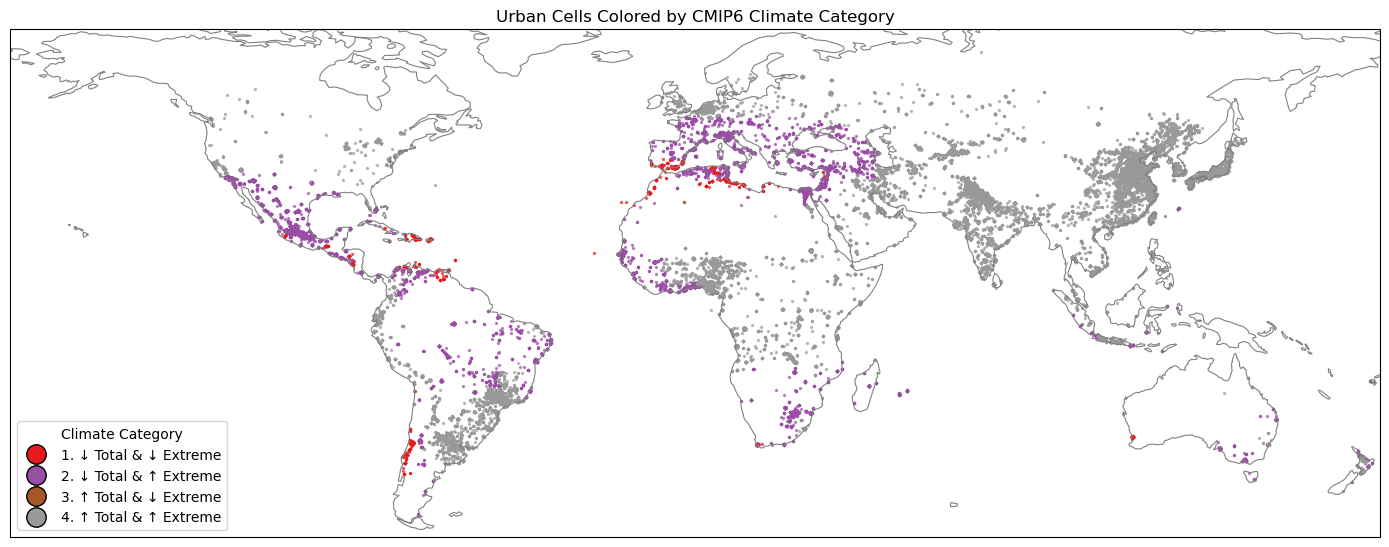

In [33]:
# Colormap mapping
cmap = plt.cm.get_cmap('Set1', 4)
cat_to_cmap_idx = {1: 0, 2: 1, 3: 2, 4: 3}

category_descriptions = {
    1: "1. ↓ Total & ↓ Extreme",
    2: "2. ↓ Total & ↑ Extreme",
    3: "3. ↑ Total & ↓ Extreme",
    4: "4. ↑ Total & ↑ Extreme"
}

# Case study locations from the literature (lat, lon)
research_locations = {
    "Minneapolis (USA)": (44.9778, -93.2650),
    "Southern Germany – Munich": (48.1351, 11.5820),
    "Northern China – Beijing": (39.9042, 116.4074),
    "Southeast Florida – Miami": (25.7617, -80.1918),
    # Optional representative point for Mediterranean European cities:
    "Mediterranean Europe – Rome": (41.9028, 12.4964),
}

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

for cat in [1, 2, 3, 4]:
    color = cmap(cat_to_cmap_idx[cat])
    subset = urban_cmip6_join[urban_cmip6_join['category'] == cat]
    if not subset.empty:
        subset_gdf = gpd.GeoDataFrame(subset, geometry='geometry', crs='EPSG:4326')
        subset_gdf.plot(
            ax=ax,
            markersize=2,
            color=color,
            alpha=0.6,
            label=category_descriptions[cat],
            transform=ccrs.PlateCarree()
        )

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.set_title("Urban Cells Colored by CMIP6 Climate Category")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Build a custom legend with big circles and full descriptions
legend_handles = [
    Line2D(
        [0], [0],
        marker='o', color='w', label=category_descriptions[cat],
        markerfacecolor=cmap(cat_to_cmap_idx[cat]), markersize=14,
        markeredgecolor='black', lw=0
    )
    for cat in [1, 2, 3, 4]
]

plt.legend(handles=legend_handles, title="Climate Category", loc="lower left")
plt.tight_layout()

# Print coordinates of the research locations
print("Research case study locations (lat, lon):")
for name, (lat, lon) in research_locations.items():
    print(f"{name}: {lat:.4f}°, {lon:.4f}°")

plt.show()


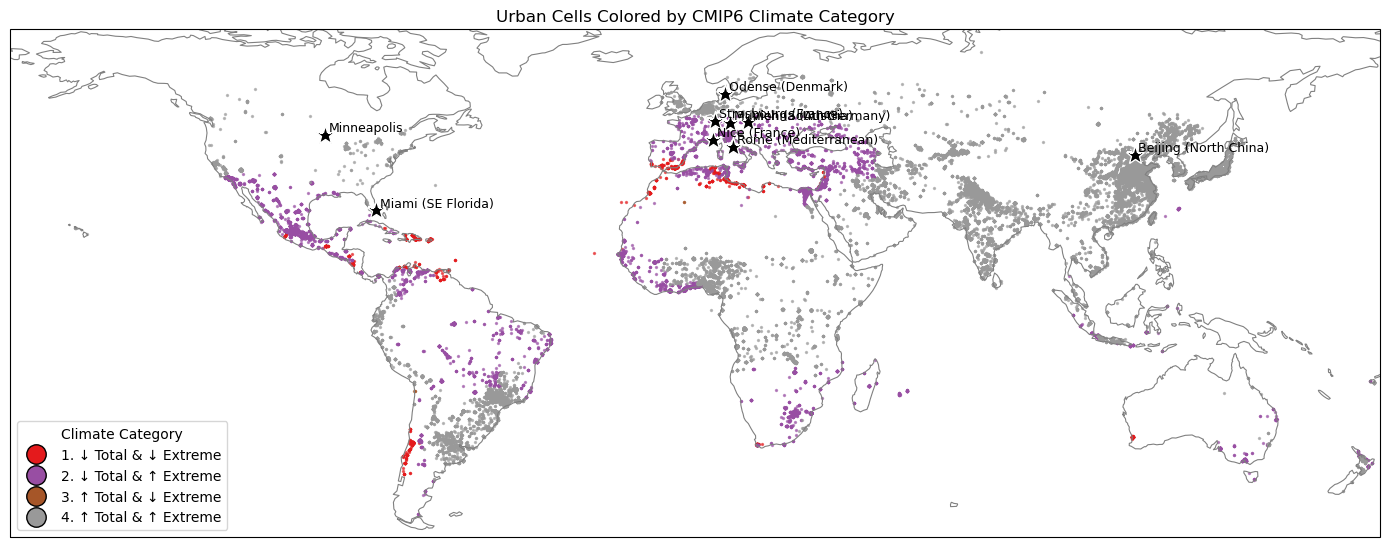

In [34]:
# Colormap mapping
cmap = plt.cm.get_cmap('Set1', 4)
cat_to_cmap_idx = {1: 0, 2: 1, 3: 2, 4: 3}

category_descriptions = {
    1: "1. ↓ Total & ↓ Extreme",
    2: "2. ↓ Total & ↑ Extreme",
    3: "3. ↑ Total & ↓ Extreme",
    4: "4. ↑ Total & ↑ Extreme"
}

# Case study locations (lat, lon)
research_locations = {
    # Previous cases
    "Minneapolis": (44.9778, -93.2650),
    "Munich (South Germany)": (48.1351, 11.5820),
    "Beijing (North China)": (39.9042, 116.4074),
    "Miami (SE Florida)": (25.7617, -80.1918),
    "Rome (Mediterranean)": (41.9028, 12.4964),

    # New cities from Kaspersen et al. (2017)
    "Odense (Denmark)": (55.4038, 10.4024),
    "Vienna (Austria)": (48.2082, 16.3738),
    "Strasbourg (France)": (48.5734, 7.7521),
    "Nice (France)": (43.7102, 7.2620),
}

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot categories
for cat in [1, 2, 3, 4]:
    color = cmap(cat_to_cmap_idx[cat])
    subset = urban_cmip6_join[urban_cmip6_join['category'] == cat]
    if not subset.empty:
        subset_gdf = gpd.GeoDataFrame(subset, geometry='geometry', crs='EPSG:4326')
        subset_gdf.plot(
            ax=ax,
            markersize=2,
            color=color,
            alpha=0.6,
            transform=ccrs.PlateCarree()
        )

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.set_title("Urban Cells Colored by CMIP6 Climate Category")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Add city markers
for city, (lat, lon) in research_locations.items():
    ax.plot(
        lon, lat,
        marker='*', markersize=14,
        color='black', markeredgecolor='white',
        transform=ccrs.PlateCarree()
    )
    ax.text(
        lon + 1.0, lat + 1.0, city,
        fontsize=9, color='black',
        transform=ccrs.PlateCarree()
    )

# Legend
legend_handles = [
    Line2D(
        [0], [0],
        marker='o', color='w',
        label=category_descriptions[cat],
        markerfacecolor=cmap(cat_to_cmap_idx[cat]),
        markersize=14, markeredgecolor='black', lw=0
    )
    for cat in [1, 2, 3, 4]
]

plt.legend(handles=legend_handles, title="Climate Category", loc="lower left")
plt.tight_layout()
plt.show()


## Major cities & selected cat

C:\Users\raznu\AppData\Local\Temp\ipykernel_40116\1108682030.py:8: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_cities' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  cities = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))


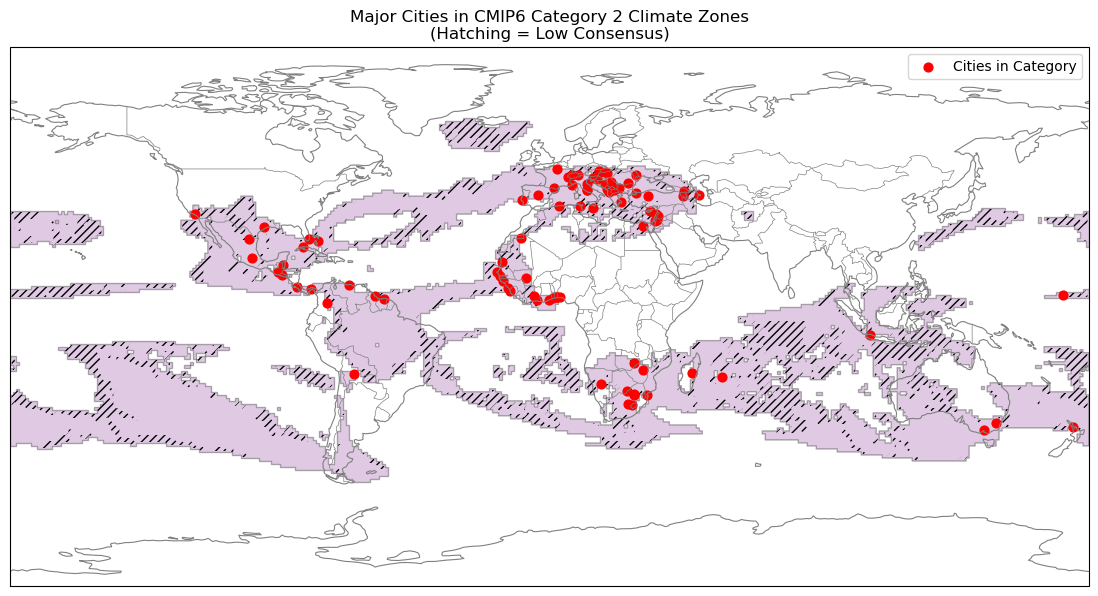

In [36]:
# Define Set1 colormap and mapping from category to color index
cmap = plt.cm.get_cmap('Set1', 4)
cat_to_cmap_idx = {1: 0, 2: 1, 3: 2, 4: 3}

selected_cat = 2

# 1. Load world cities (built-in geopandas dataset)
cities = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))

# 2. Filter polygons for the selected category
cat_polygons = cmip6_cat_gdf[cmip6_cat_gdf['category'] == selected_cat]

# 3. Spatial join: find cities within selected category polygons
cities_in_cat = gpd.sjoin(cities, cat_polygons, how='inner', predicate='within')

# 4. Prepare low-agreement mask for this category (boolean mask where consensus is low and category == selected_cat)
# Assumes: classification (xarray.DataArray), low_agreement_mask (np.ndarray), data_total.lon/lat
selected_cat_mask = (classification.values == selected_cat)
hatch_mask = np.where(selected_cat_mask & low_agreement_mask, 1, np.nan)

# 5. Plot: climate category polygons and included cities with hatch for low agreement
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot selected category polygons (color from Set1 colormap)
color = cmap(cat_to_cmap_idx[selected_cat])
cat_polygons.plot(
    ax=ax,
    color=color, alpha=0.3, edgecolor='black',
    transform=ccrs.PlateCarree(),
    label=f"CMIP Category {selected_cat}"
)

# Hatching: overlay only where selected_cat & low consensus
ax.contourf(
    data_total.lon, data_total.lat, hatch_mask, levels=1,
    hatches=['////'], colors='none', transform=ccrs.PlateCarree()
)

# Plot cities as red points
cities_in_cat.plot(
    ax=ax,
    color='red', markersize=40,
    label='Cities in Category',
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.set_title(f'Major Cities in CMIP6 Category {selected_cat} Climate Zones\n(Hatching = Low Consensus)')
plt.legend()
plt.show()


In [37]:
selected_cat = 2
cat_polygons = cmip6_cat_gdf[cmip6_cat_gdf['category'] == selected_cat]
cities = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))
cities_in_cat = gpd.sjoin(cities, cat_polygons, how='inner', predicate='within')

# Create a folium map centered globally
m = folium.Map(location=[20, 0], zoom_start=2, tiles="cartodbpositron")

# Add the CMIP6 polygons (use a single color for simplicity)
folium.GeoJson(
    cat_polygons.to_crs(epsg=4326),
    style_function=lambda x: {"color": "#377eb8", "fillOpacity": 0.3, "weight": 1},
    name=f"CMIP Category {selected_cat}"
).add_to(m)

# Add the cities with tooltips (hover)
for idx, row in cities_in_cat.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6,
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.8,
        tooltip=row['name']  # Show name on hover
    ).add_to(m)

folium.LayerControl().add_to(m)

# To display in Jupyter:
m


C:\Users\raznu\AppData\Local\Temp\ipykernel_40116\1149395387.py:3: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_cities' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  cities = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))


In [38]:
cities_in_cat.explore(
    column="name",  # shows popup on click, name on hover
    popup=True,
    tooltip="name",
    marker_kwds=dict(radius=8, color='red', fill=True, fill_color='red')
)


SystemError: initialization of _internal failed without raising an exception

In [ ]:
cities_in_cat



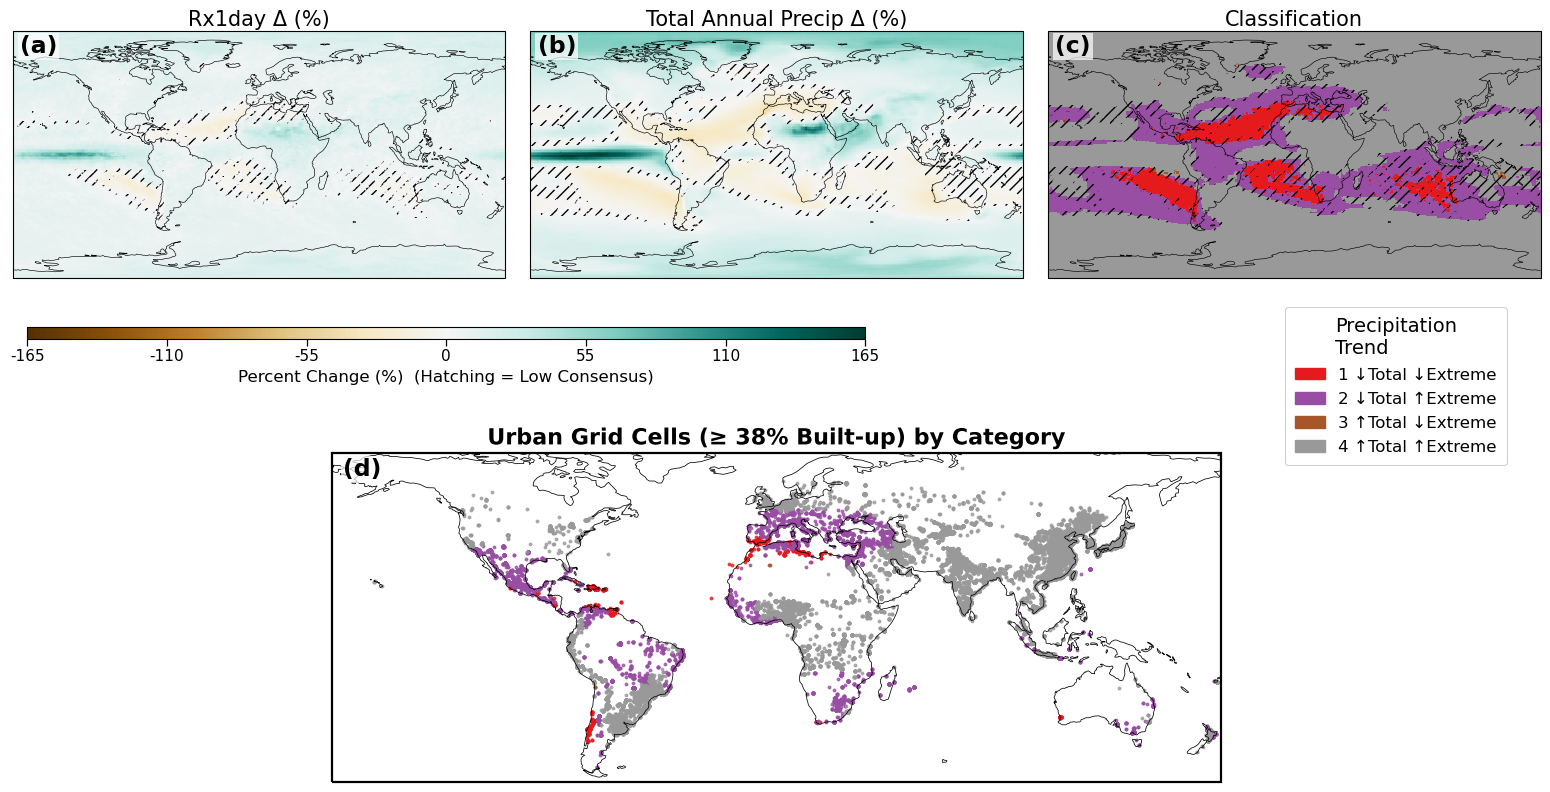

In [ ]:
# === Final 4-panel publication figure (compact layout, improved classification legend) ===
# Top row: (a) Rx1day | (b) Total annual | (c) Classification
# Bottom row: (d) Urban cells (≥ threshold% built-up)

import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects as pe
from matplotlib.patches import Patch

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

fig = plt.figure(figsize=(16, 9.5))
# Allow a little more right margin space for external legend
gs = GridSpec(2, 3, height_ratios=[14, 9], hspace=0.10, wspace=0.05)

cont_cmap = 'BrBG'
combined_max = np.nanmax(np.abs([data_rx.min(), data_rx.max(), data_total.min(), data_total.max()]))
nice_max = float(np.ceil(combined_max / 5) * 5)
vmin, vmax = -nice_max, nice_max

panel_letter_style = dict(fontsize=17, fontweight='bold')
panel_box = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)

from numpy import nan, where

def add_hatching(ax, lon, lat, mask_bool):
    if mask_bool is not None and getattr(mask_bool, 'any', lambda: False)():
        ax.contourf(lon, lat, where(mask_bool, 1, nan), levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())

# (a)
ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
data_rx.plot(ax=ax_a, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax_a.coastlines(resolution='110m', linewidth=0.45)
add_hatching(ax_a, data_rx.lon, data_rx.lat, (consensus_rx < consensus_threshold))
ax_a.set_title('Rx1day Δ (%)', pad=4)
ax_a.text(0.015, 0.985, '(a)', transform=ax_a.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

# (b)
ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
data_total.plot(ax=ax_b, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax_b.coastlines(resolution='110m', linewidth=0.45)
add_hatching(ax_b, data_total.lon, data_total.lat, (consensus_total < consensus_threshold))
ax_b.set_title('Total Annual Precip Δ (%)', pad=4)
ax_b.text(0.015, 0.985, '(b)', transform=ax_b.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

# Shared colorbar under (a)+(b)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax_ab = inset_axes(ax_b, width='100%', height='5.2%', loc='lower center',
                    bbox_to_anchor=(-1.02, -0.25, 1.70, 1), bbox_transform=ax_b.transAxes, borderpad=0)
cb_norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(cax_ab, cmap=plt.get_cmap(cont_cmap), norm=cb_norm, orientation='horizontal')
cb_ticks = np.linspace(vmin, vmax, 7)
cb.set_ticks(cb_ticks)
cb.ax.set_xticklabels([f'{t:.0f}' for t in cb_ticks])
cb.ax.tick_params(labelsize=11, length=5, width=0.9, pad=2)
cb.set_label('Percent Change (%)  (Hatching = Low Consensus)', fontsize=12, labelpad=4)

# (c)
ax_c = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
class_cmap = plt.cm.get_cmap('Set1', 4)
classification.plot(ax=ax_c, transform=ccrs.PlateCarree(), cmap=class_cmap, add_colorbar=False)
low_agree = (consensus_total < consensus_threshold) | (consensus_rx < consensus_threshold)
add_hatching(ax_c, data_total.lon, data_total.lat, low_agree)
ax_c.coastlines(resolution='110m', linewidth=0.45)
ax_c.set_title('Classification', pad=4)
ax_c.text(0.015, 0.985, '(c)', transform=ax_c.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

# Improved external legend aligned with classification panel height
class_labels = [
    Patch(color=class_cmap(0), label='1 ↓Total ↓Extreme'),
    Patch(color=class_cmap(1), label='2 ↓Total ↑Extreme'),
    Patch(color=class_cmap(2), label='3 ↑Total ↓Extreme'),
    Patch(color=class_cmap(3), label='4 ↑Total ↑Extreme')
]
# Position legend to the right of classification panel
pos_c = ax_c.get_position(fig)
legend_x = pos_c.x1 -0.08
legend_y = pos_c.y0- 0.2
legend_w = 0.14
legend_h = pos_c.height
legend_ax = fig.add_axes([legend_x, legend_y, legend_w, legend_h])
legend_ax.axis('off')
legend = legend_ax.legend(handles=class_labels, title='Precipitation\nTrend', loc='center left', frameon=True,
                          fontsize=12, title_fontsize=14, borderpad=0.6, labelspacing=0.55, handlelength=1.8)
legend.get_frame().set_alpha(0.92)
legend.get_frame().set_linewidth(0.8)

# (d)
ax_d = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
for spine in ax_d.spines.values():
    spine.set_linewidth(1.6)
if 'urban_cmip6_join' in globals() and not urban_cmip6_join.empty:
    for cat in [1,2,3,4]:
        sub = urban_cmip6_join[urban_cmip6_join['category']==cat]
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry='geometry', crs='EPSG:4326').plot(
                ax=ax_d, markersize=3.3, color=class_cmap(cat-1), alpha=0.75, transform=ccrs.PlateCarree())
ax_d.coastlines(resolution='110m', linewidth=0.55)
try:
    urban_threshold = int(threshold)
except Exception:
    urban_threshold = 0

title_d = ax_d.set_title(f'Urban Grid Cells (≥ {urban_threshold}% Built-up) by Category', fontsize=16, pad=6, fontweight='bold')
import matplotlib.patheffects as patheffects
title_d.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
ax_d.text(0.012, 0.985, '(d)', transform=ax_d.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)


plt.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.04)

# === Save as PDF ===
out_dir = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, "Fig_1.pdf")
fig.savefig(fig_path, format="pdf", dpi=300)

plt.show()


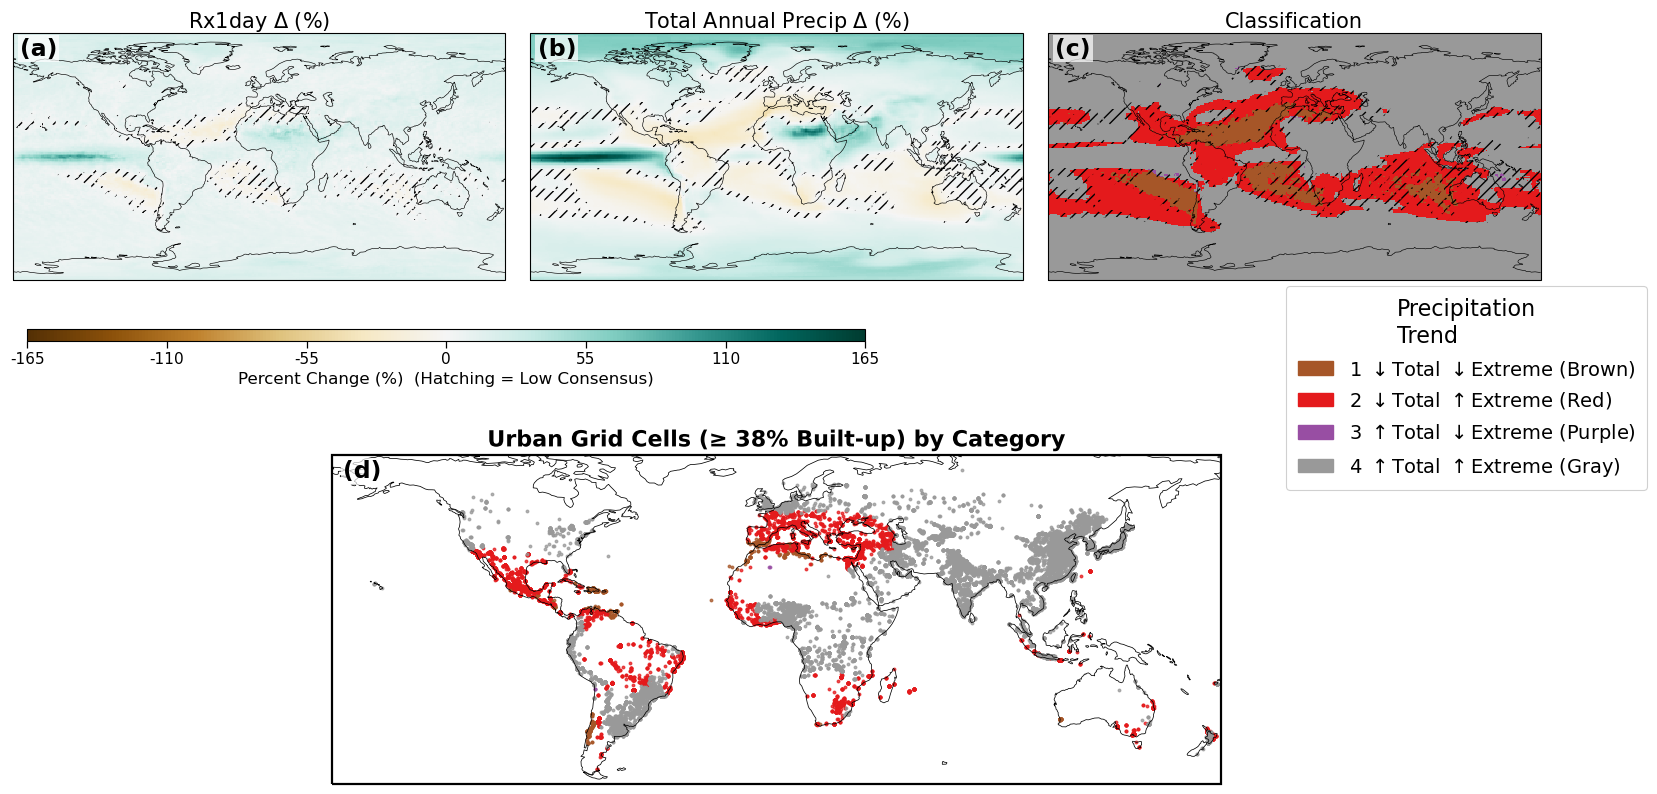

In [ ]:
# === Final 4-panel publication figure (compact layout, improved classification legend) ===
# Top row: (a) Rx1day | (b) Total annual | (c) Classification
# Bottom row: (d) Urban cells (>= threshold% built-up)

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects as pe
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import numpy as np
import geopandas as gpd
import cartopy.crs as ccrs
import os
from numpy import nan, where

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

fig = plt.figure(figsize=(16, 9.5))
# Allow a little more right margin space for external legend
gs = GridSpec(2, 3, height_ratios=[14, 9], hspace=0.10, wspace=0.05)

cont_cmap = 'BrBG'
combined_max = np.nanmax(np.abs([data_rx.min(), data_rx.max(), data_total.min(), data_total.max()]))
nice_max = float(np.ceil(combined_max / 5) * 5)
vmin, vmax = -nice_max, nice_max

panel_letter_style = dict(fontsize=17, fontweight='bold')
panel_box = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)

def add_hatching(ax, lon, lat, mask_bool):
    """Adds hatching to areas with low statistical consensus."""
    if mask_bool is not None and getattr(mask_bool, 'any', lambda: False)():
        ax.contourf(lon, lat, where(mask_bool, 1, nan), levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())

# (a) Rx1day Delta
ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
data_rx.plot(ax=ax_a, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax_a.coastlines(resolution='110m', linewidth=0.45)
add_hatching(ax_a, data_rx.lon, data_rx.lat, (consensus_rx < consensus_threshold))
ax_a.set_title('Rx1day $\Delta$ (%)', pad=4)
ax_a.text(0.015, 0.985, '(a)', transform=ax_a.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

# (b) Total Annual Precip Delta
ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
data_total.plot(ax=ax_b, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax_b.coastlines(resolution='110m', linewidth=0.45)
add_hatching(ax_b, data_total.lon, data_total.lat, (consensus_total < consensus_threshold))
ax_b.set_title('Total Annual Precip $\Delta$ (%)', pad=4)
ax_b.text(0.015, 0.985, '(b)', transform=ax_b.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

# Shared colorbar under (a)+(b)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax_ab = inset_axes(ax_b, width='100%', height='5.2%', loc='lower center',
                    bbox_to_anchor=(-1.02, -0.25, 1.70, 1), bbox_transform=ax_b.transAxes, borderpad=0)
cb_norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(cax_ab, cmap=plt.get_cmap(cont_cmap), norm=cb_norm, orientation='horizontal')
cb_ticks = np.linspace(vmin, vmax, 7)
cb.set_ticks(cb_ticks)
cb.ax.set_xticklabels([f'{t:.0f}' for t in cb_ticks])
cb.ax.tick_params(labelsize=11, length=5, width=0.9, pad=2)
cb.set_label('Percent Change (%)  (Hatching = Low Consensus)', fontsize=12, labelpad=4)

# (c) Classification
ax_c = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())

# --- CUSTOM COLOR DEFINITION ---
# 1. Brown  (#a65628): Both decrease
# 2. Red    (#e41a1c): Total decreases, Extreme increases (Hotspot)
# 3. Purple (#984ea3): Total increases, Extreme decreases
# 4. Gray   (#999999): Both increase
custom_colors = ['#a65628', '#e41a1c', '#984ea3', '#999999']
class_cmap = ListedColormap(custom_colors)

classification.plot(ax=ax_c, transform=ccrs.PlateCarree(), cmap=class_cmap, add_colorbar=False)
low_agree = (consensus_total < consensus_threshold) | (consensus_rx < consensus_threshold)
add_hatching(ax_c, data_total.lon, data_total.lat, low_agree)
ax_c.coastlines(resolution='110m', linewidth=0.45)
ax_c.set_title('Classification', pad=4)
ax_c.text(0.015, 0.985, '(c)', transform=ax_c.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

# Improved external legend
# Using raw strings (r'') to prevent latex errors
class_labels = [
    Patch(color=custom_colors[0], label=r'1 $\downarrow$Total $\downarrow$Extreme (Brown)'),
    Patch(color=custom_colors[1], label=r'2 $\downarrow$Total $\uparrow$Extreme (Red)'),
    Patch(color=custom_colors[2], label=r'3 $\uparrow$Total $\downarrow$Extreme (Purple)'),
    Patch(color=custom_colors[3], label=r'4 $\uparrow$Total $\uparrow$Extreme (Gray)')
]

# Position legend to the right of classification panel
pos_c = ax_c.get_position(fig)
legend_x = pos_c.x1 -0.08
legend_y = pos_c.y0- 0.2
legend_w = 0.14
legend_h = pos_c.height
legend_ax = fig.add_axes([legend_x, legend_y, legend_w, legend_h])
legend_ax.axis('off')
legend = legend_ax.legend(handles=class_labels, title='Precipitation\nTrend', loc='center left', frameon=True,
                          fontsize=14, title_fontsize=16, borderpad=0.6, labelspacing=0.55, handlelength=1.8)
legend.get_frame().set_alpha(0.92)
legend.get_frame().set_linewidth(0.8)

# (d) Urban Grid Cells
ax_d = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
for spine in ax_d.spines.values():
    spine.set_linewidth(1.6)

if 'urban_cmip6_join' in globals() and not urban_cmip6_join.empty:
    for cat in [1,2,3,4]:
        sub = urban_cmip6_join[urban_cmip6_join['category']==cat]
        if not sub.empty:
            # Note: class_cmap is 0-indexed, so we use cat-1
            gpd.GeoDataFrame(sub, geometry='geometry', crs='EPSG:4326').plot(
                ax=ax_d, markersize=3.3, color=class_cmap(cat-1), alpha=0.75, transform=ccrs.PlateCarree())

ax_d.coastlines(resolution='110m', linewidth=0.55)
try:
    urban_threshold = int(threshold)
except Exception:
    urban_threshold = 0

title_d = ax_d.set_title(f'Urban Grid Cells (≥ {urban_threshold}% Built-up) by Category', fontsize=16, pad=6, fontweight='bold')
import matplotlib.patheffects as patheffects
title_d.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
ax_d.text(0.012, 0.985, '(d)', transform=ax_d.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)


plt.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.04)

# === Save as PDF ===
out_dir = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, "Fig_1_CustomColors.pdf")
fig.savefig(fig_path, format="pdf", dpi=300)

plt.show()

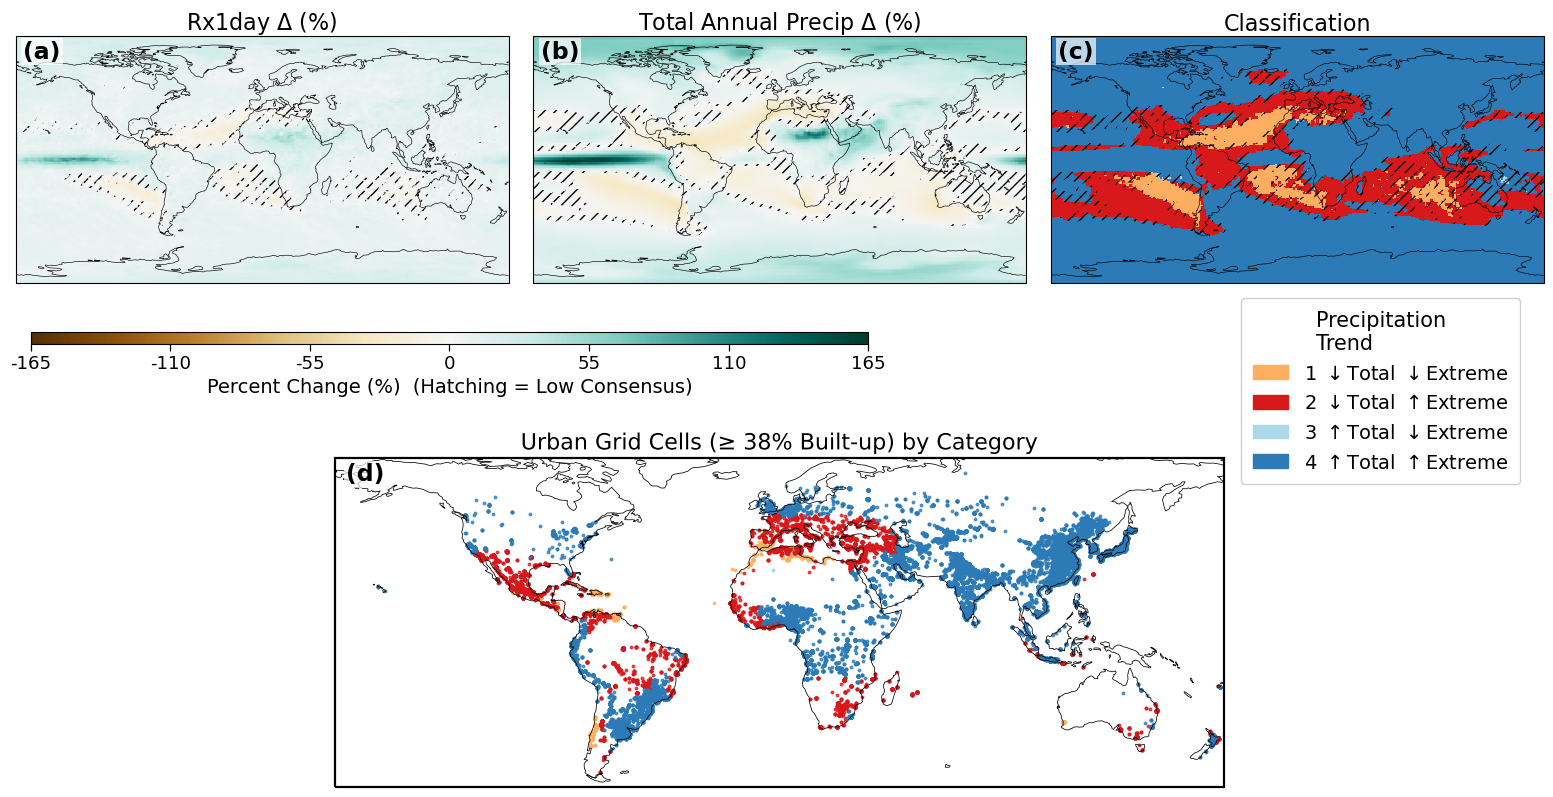

In [ ]:
# === Final 4-panel publication figure (Colorblind safe, High Contrast) ===
# Top row: (a) Rx1day | (b) Total annual | (c) Classification
# Bottom row: (d) Urban cells

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import geopandas as gpd
import cartopy.crs as ccrs
import os
from numpy import nan, where

# Global styling
mpl.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# Title / colorbar sizing (requested: all titles same size; colorbar text larger)
TITLE_FONTSIZE = 16
CB_TICK_FONTSIZE = 13
CB_LABEL_FONTSIZE = 14

fig = plt.figure(figsize=(16, 9.5))
gs = GridSpec(2, 3, height_ratios=[14, 9], hspace=0.10, wspace=0.05)

cont_cmap = 'BrBG'
combined_max = np.nanmax(np.abs([data_rx.min(), data_rx.max(), data_total.min(), data_total.max()]))
nice_max = float(np.ceil(combined_max / 5) * 5)
vmin, vmax = -nice_max, nice_max
panel_letter_style = dict(fontsize=17, fontweight='bold')
panel_box = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)

def add_hatching(ax, lon, lat, mask_bool):
    if mask_bool is not None and getattr(mask_bool, 'any', lambda: False)():
        ax.contourf(
            lon, lat, where(mask_bool, 1, nan),
            levels=1, hatches=['///'], colors='none',
            transform=ccrs.PlateCarree()
        )

# (a) Rx1day
ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
data_rx.plot(ax=ax_a, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax_a.coastlines(resolution='110m', linewidth=0.45)
add_hatching(ax_a, data_rx.lon, data_rx.lat, (consensus_rx < consensus_threshold))
ax_a.set_title(r'Rx1day $\Delta$ (%)', pad=4, fontsize=TITLE_FONTSIZE)
ax_a.text(0.015, 0.985, '(a)', transform=ax_a.transAxes, ha='left', va='top',
          **panel_letter_style, bbox=panel_box)

# (b) Total Annual
ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
data_total.plot(ax=ax_b, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax_b.coastlines(resolution='110m', linewidth=0.45)
add_hatching(ax_b, data_total.lon, data_total.lat, (consensus_total < consensus_threshold))
ax_b.set_title(r'Total Annual Precip $\Delta$ (%)', pad=4, fontsize=TITLE_FONTSIZE)
ax_b.text(0.015, 0.985, '(b)', transform=ax_b.transAxes, ha='left', va='top',
          **panel_letter_style, bbox=panel_box)

# Shared colorbar
cax_ab = inset_axes(
    ax_b, width='100%', height='5.2%', loc='lower center',
    bbox_to_anchor=(-1.02, -0.25, 1.70, 1), bbox_transform=ax_b.transAxes, borderpad=0
)
cb_norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(
    cax_ab, cmap=plt.get_cmap(cont_cmap), norm=cb_norm, orientation='horizontal'
)
cb_ticks = np.linspace(vmin, vmax, 7)
cb.set_ticks(cb_ticks)
cb.ax.set_xticklabels([f'{t:.0f}' for t in cb_ticks])
cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE, length=5, width=0.9, pad=2)
cb.set_label('Percent Change (%)  (Hatching = Low Consensus)', fontsize=CB_LABEL_FONTSIZE, labelpad=4)

# (c) Classification
ax_c = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())

# --- NEW COLOR PALETTE (Colorblind Safe & Distinct) ---
custom_colors = ['#fdae61', '#d7191c', '#abd9e9', '#2c7bb6']
class_cmap = ListedColormap(custom_colors)

classification.plot(ax=ax_c, transform=ccrs.PlateCarree(), cmap=class_cmap, add_colorbar=False)
low_agree = (consensus_total < consensus_threshold) | (consensus_rx < consensus_threshold)
add_hatching(ax_c, data_total.lon, data_total.lat, low_agree)
ax_c.coastlines(resolution='110m', linewidth=0.45)
ax_c.set_title('Classification', pad=4, fontsize=TITLE_FONTSIZE)
ax_c.text(0.015, 0.985, '(c)', transform=ax_c.transAxes, ha='left', va='top',
          **panel_letter_style, bbox=panel_box)

# Legend
class_labels = [
    Patch(color=custom_colors[0], label=r'1 $\downarrow$Total $\downarrow$Extreme'),
    Patch(color=custom_colors[1], label=r'2 $\downarrow$Total $\uparrow$Extreme'),
    Patch(color=custom_colors[2], label=r'3 $\uparrow$Total $\downarrow$Extreme'),
    Patch(color=custom_colors[3], label=r'4 $\uparrow$Total $\uparrow$Extreme')
]

pos_c = ax_c.get_position(fig)
legend_ax = fig.add_axes([pos_c.x1 - 0.11, pos_c.y0 - 0.2, 0.14, pos_c.height])
legend_ax.axis('off')
legend = legend_ax.legend(
    handles=class_labels, title='Precipitation\nTrend', loc='center left', frameon=True,
    fontsize=14, title_fontsize=15, borderpad=0.6, labelspacing=0.55, handlelength=1.8
)
legend.get_frame().set_alpha(0.92)

# (d) Urban Grid Cells
ax_d = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
for spine in ax_d.spines.values():
    spine.set_linewidth(1.6)

if 'urban_cmip6_join' in globals() and not urban_cmip6_join.empty:
    for cat in [1, 2, 3, 4]:
        sub = urban_cmip6_join[urban_cmip6_join['category'] == cat]
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry='geometry', crs='EPSG:4326').plot(
                ax=ax_d, markersize=3.3, color=class_cmap(cat - 1), alpha=0.75,
                transform=ccrs.PlateCarree()
            )

ax_d.coastlines(resolution='110m', linewidth=0.55)
try:
    urban_threshold = int(threshold)
except Exception:
    urban_threshold = 0

# Requested changes:
# 1) Panel (d) title NOT bold
# 2) All titles same fontsize
title_d = ax_d.set_title(
    f'Urban Grid Cells (≥ {urban_threshold}% Built-up) by Category',
    fontsize=TITLE_FONTSIZE, pad=6, fontweight='normal'
)

import matplotlib.patheffects as patheffects
title_d.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])

ax_d.text(0.012, 0.985, '(d)', transform=ax_d.transAxes, ha='left', va='top',
          **panel_letter_style, bbox=panel_box)

plt.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.04)

out_dir = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, "Fig_1_ColorblindSafe.pdf")

fig.savefig(
    fig_path,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    bbox_extra_artists=[legend]
)


plt.show()


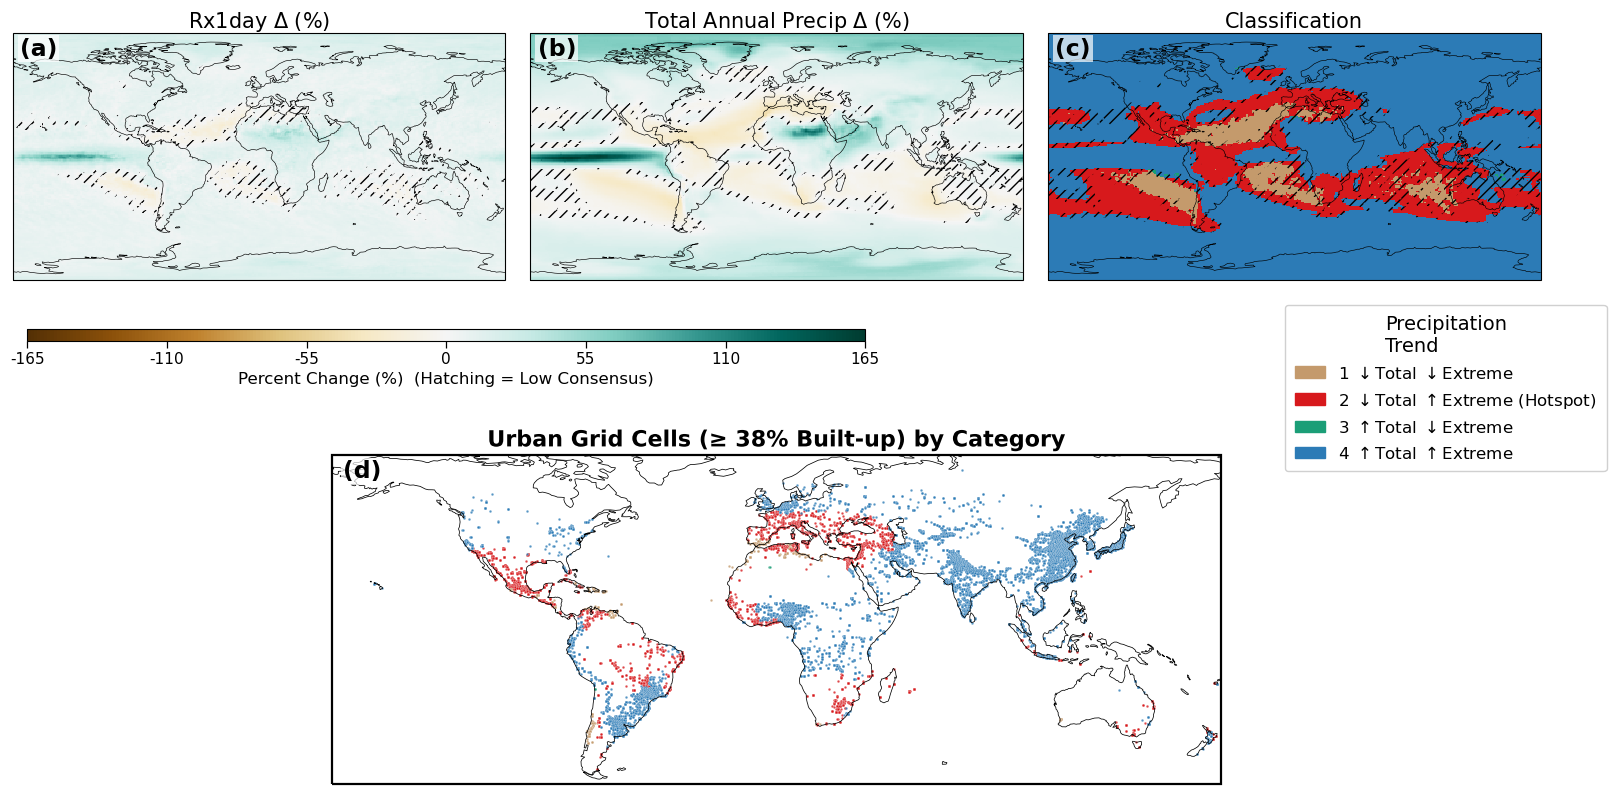

In [ ]:
# === Final 4-panel publication figure (Colorblind safe, High Contrast) ===
# Top row: (a) Rx1day | (b) Total annual | (c) Classification
# Bottom row: (d) Urban cells

import os
import numpy as np
from numpy import nan, where

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as patheffects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import geopandas as gpd
import cartopy.crs as ccrs

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ---------------------------------------------------------
# Helper
# ---------------------------------------------------------
panel_letter_style = dict(fontsize=17, fontweight="bold")
panel_box = dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5)

def add_hatching(ax, lon, lat, mask_bool):
    if mask_bool is not None and getattr(mask_bool, "any", lambda: False)():
        ax.contourf(
            lon, lat,
            where(mask_bool, 1, nan),
            levels=1,
            hatches=["///"],
            colors="none",
            transform=ccrs.PlateCarree()
        )

# ---------------------------------------------------------
# Figure layout
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 9.5))
gs = GridSpec(2, 3, height_ratios=[14, 9], hspace=0.10, wspace=0.05)

# Continuous maps scaling (shared between a and b)
cont_cmap = "BrBG"
combined_max = np.nanmax(np.abs([
    float(np.nanmin(data_rx.values)), float(np.nanmax(data_rx.values)),
    float(np.nanmin(data_total.values)), float(np.nanmax(data_total.values))
]))
nice_max = float(np.ceil(combined_max / 5) * 5)
vmin, vmax = -nice_max, nice_max

# ---------------------------------------------------------
# (a) Rx1day
# ---------------------------------------------------------
ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
data_rx.plot(
    ax=ax_a,
    transform=ccrs.PlateCarree(),
    cmap=cont_cmap,
    vmin=vmin, vmax=vmax,
    add_colorbar=False
)
ax_a.coastlines(resolution="110m", linewidth=0.45)
add_hatching(ax_a, data_rx.lon, data_rx.lat, (consensus_rx < consensus_threshold))
ax_a.set_title(r"Rx1day $\Delta$ (%)", pad=4)
ax_a.text(0.015, 0.985, "(a)", transform=ax_a.transAxes,
          ha="left", va="top", **panel_letter_style, bbox=panel_box)

# ---------------------------------------------------------
# (b) Total annual
# ---------------------------------------------------------
ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
data_total.plot(
    ax=ax_b,
    transform=ccrs.PlateCarree(),
    cmap=cont_cmap,
    vmin=vmin, vmax=vmax,
    add_colorbar=False
)
ax_b.coastlines(resolution="110m", linewidth=0.45)
add_hatching(ax_b, data_total.lon, data_total.lat, (consensus_total < consensus_threshold))
ax_b.set_title(r"Total Annual Precip $\Delta$ (%)", pad=4)
ax_b.text(0.015, 0.985, "(b)", transform=ax_b.transAxes,
          ha="left", va="top", **panel_letter_style, bbox=panel_box)

# Shared colorbar for (a) and (b)
cax_ab = inset_axes(
    ax_b,
    width="100%", height="5.2%",
    loc="lower center",
    bbox_to_anchor=(-1.02, -0.25, 1.70, 1),
    bbox_transform=ax_b.transAxes,
    borderpad=0
)
cb_norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(
    cax_ab,
    cmap=plt.get_cmap(cont_cmap),
    norm=cb_norm,
    orientation="horizontal"
)
cb_ticks = np.linspace(vmin, vmax, 7)
cb.set_ticks(cb_ticks)
cb.ax.set_xticklabels([f"{t:.0f}" for t in cb_ticks])
cb.ax.tick_params(labelsize=11, length=5, width=0.9, pad=2)
cb.set_label("Percent Change (%)  (Hatching = Low Consensus)", fontsize=12, labelpad=4)

# ---------------------------------------------------------
# (c) Classification (intuitive, Nature style, colorblind safe)
# Category meaning:
# 1: ↓Total ↓Extreme  (drier, less extreme)         earth brown
# 2: ↓Total ↑Extreme  (contradictory hotspot)       red
# 3: ↑Total ↓Extreme  (wetter, less extreme)        teal
# 4: ↑Total ↑Extreme  (wetter, more extreme)        deep blue
# ---------------------------------------------------------
custom_colors = ["#C49A6C", "#D7191C", "#1B9E77", "#2C7BB6"]
class_cmap = ListedColormap(custom_colors)

ax_c = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
classification.plot(
    ax=ax_c,
    transform=ccrs.PlateCarree(),
    cmap=class_cmap,
    add_colorbar=False
)

low_agree = (consensus_total < consensus_threshold) | (consensus_rx < consensus_threshold)
add_hatching(ax_c, data_total.lon, data_total.lat, low_agree)

ax_c.coastlines(resolution="110m", linewidth=0.45)
ax_c.set_title("Classification", pad=4)
ax_c.text(0.015, 0.985, "(c)", transform=ax_c.transAxes,
          ha="left", va="top", **panel_letter_style, bbox=panel_box)

class_labels = [
    Patch(color=custom_colors[0], label=r"1 $\downarrow$Total $\downarrow$Extreme"),
    Patch(color=custom_colors[1], label=r"2 $\downarrow$Total $\uparrow$Extreme (Hotspot)"),
    Patch(color=custom_colors[2], label=r"3 $\uparrow$Total $\downarrow$Extreme"),
    Patch(color=custom_colors[3], label=r"4 $\uparrow$Total $\uparrow$Extreme")
]

pos_c = ax_c.get_position(fig)
legend_ax = fig.add_axes([pos_c.x1 - 0.08, pos_c.y0 - 0.2, 0.14, pos_c.height])
legend_ax.axis("off")
legend = legend_ax.legend(
    handles=class_labels,
    title="Precipitation\nTrend",
    loc="center left",
    frameon=True,
    fontsize=12,
    title_fontsize=14,
    borderpad=0.6,
    labelspacing=0.55,
    handlelength=1.8
)
legend.get_frame().set_alpha(0.92)

# ---------------------------------------------------------
# (d) Urban grid cells by category (use thin white edge to improve readability)
# ---------------------------------------------------------
ax_d = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
for spine in ax_d.spines.values():
    spine.set_linewidth(1.6)

if "urban_cmip6_join" in globals() and (urban_cmip6_join is not None) and (not urban_cmip6_join.empty):
    for cat in [1, 2, 3, 4]:
        sub = urban_cmip6_join[urban_cmip6_join["category"] == cat]
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry="geometry", crs="EPSG:4326").plot(
                ax=ax_d,
                markersize=3.3,
                color=class_cmap(cat - 1),
                edgecolor="white",
                linewidth=0.15,
                alpha=0.80,
                transform=ccrs.PlateCarree()
            )

ax_d.coastlines(resolution="110m", linewidth=0.55)

try:
    urban_threshold = int(threshold)
except Exception:
    urban_threshold = 0

title_d = ax_d.set_title(
    f"Urban Grid Cells (≥ {urban_threshold}% Built-up) by Category",
    fontsize=16,
    pad=6,
    fontweight="bold"
)
title_d.set_path_effects([patheffects.withStroke(linewidth=3, foreground="white")])
ax_d.text(0.012, 0.985, "(d)", transform=ax_d.transAxes,
          ha="left", va="top", **panel_letter_style, bbox=panel_box)

plt.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.04)

out_dir = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"
os.makedirs(out_dir, exist_ok=True)
fig_path = os.path.join(out_dir, "Fig_1_ColorblindSafe.pdf")
fig.savefig(fig_path, format="pdf", dpi=300)

plt.show()


Displaying Figure Option 1...


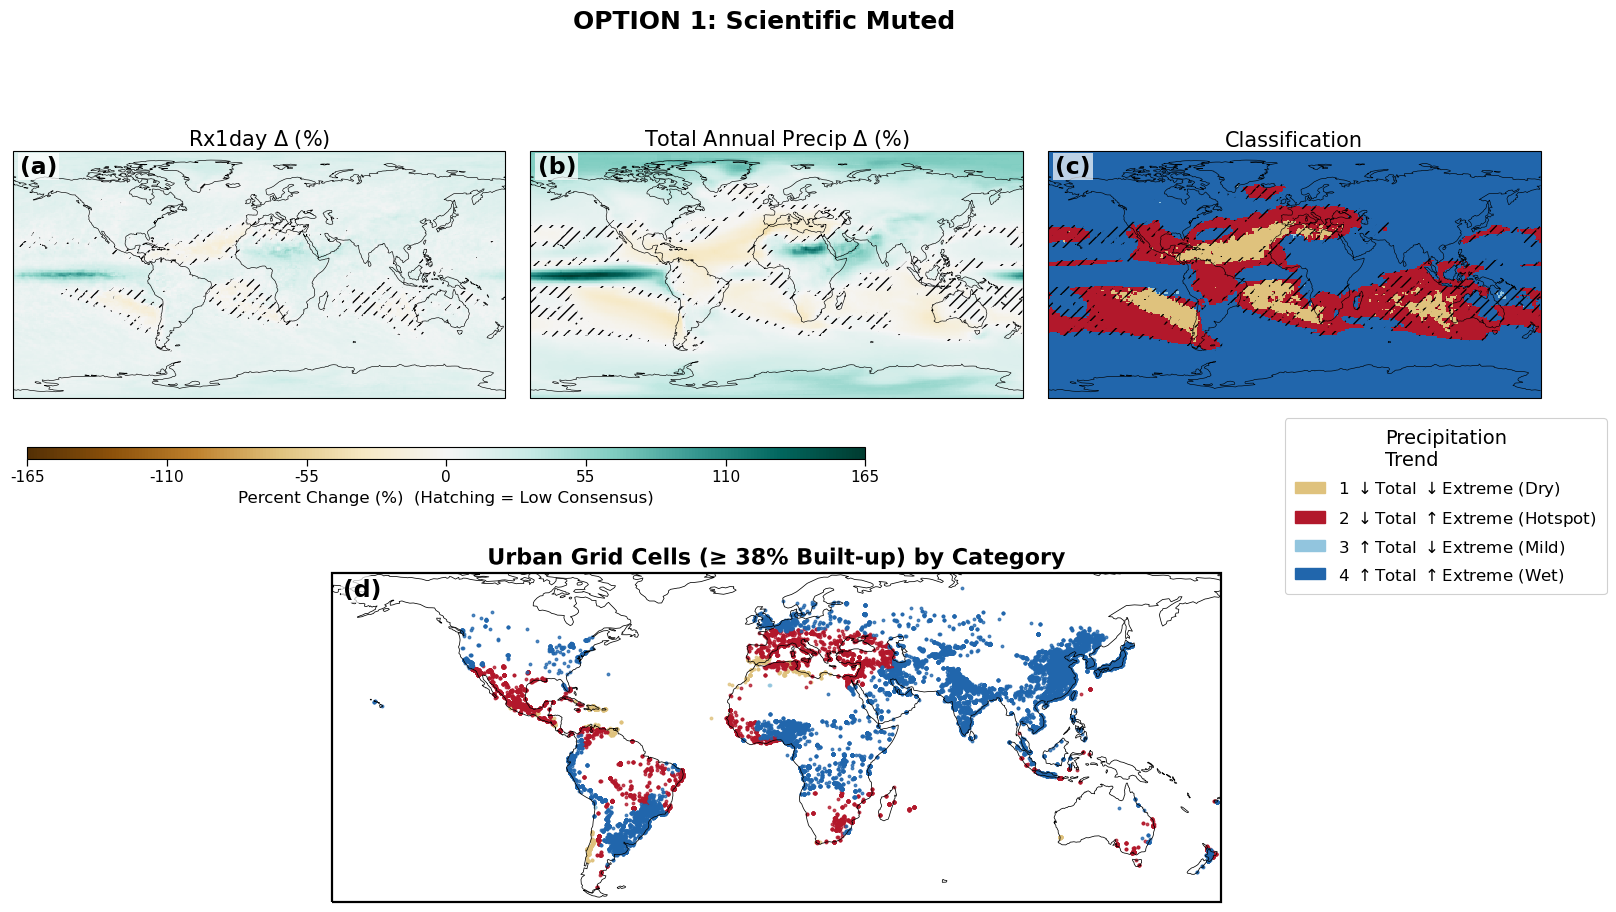

Displaying Figure Option 2...


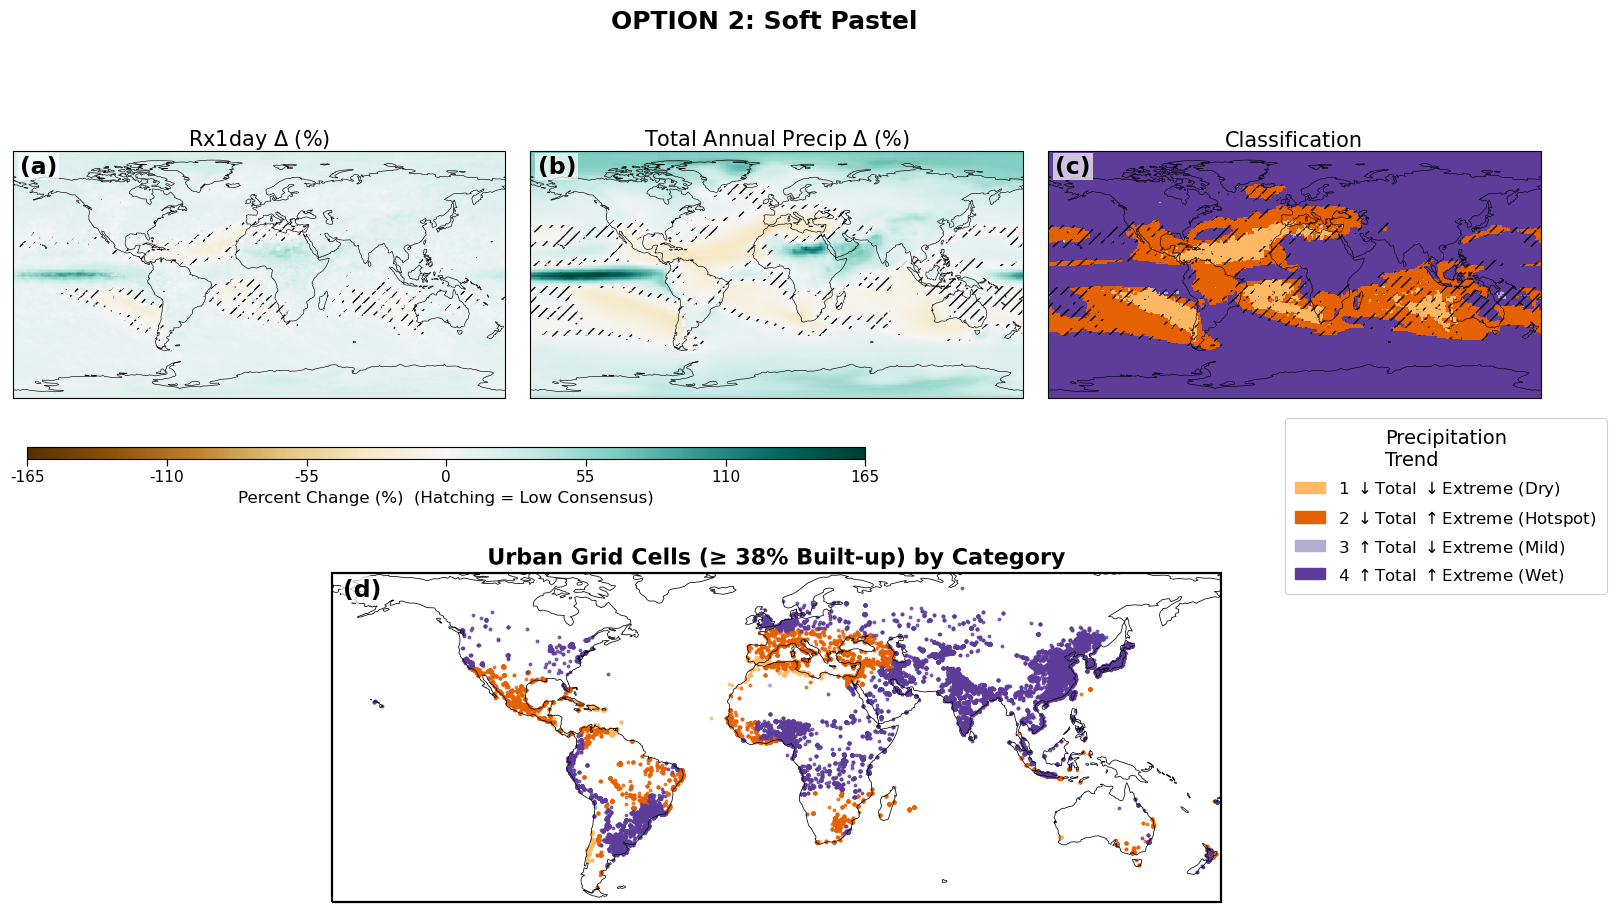

Displaying Figure Option 3...


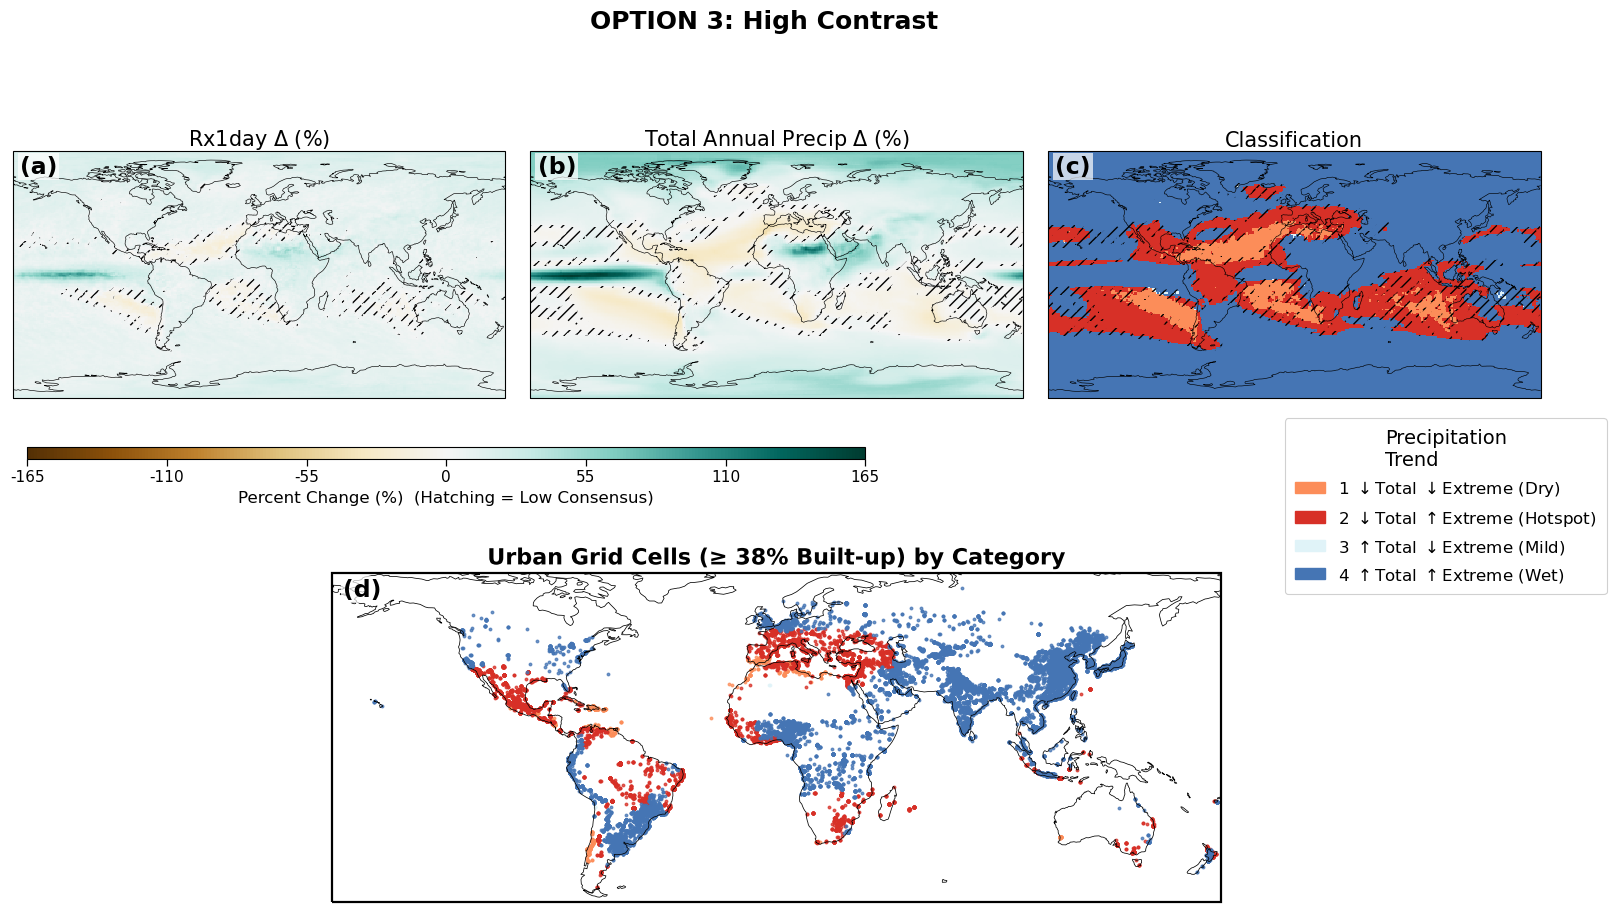

Displaying Figure Option 4...


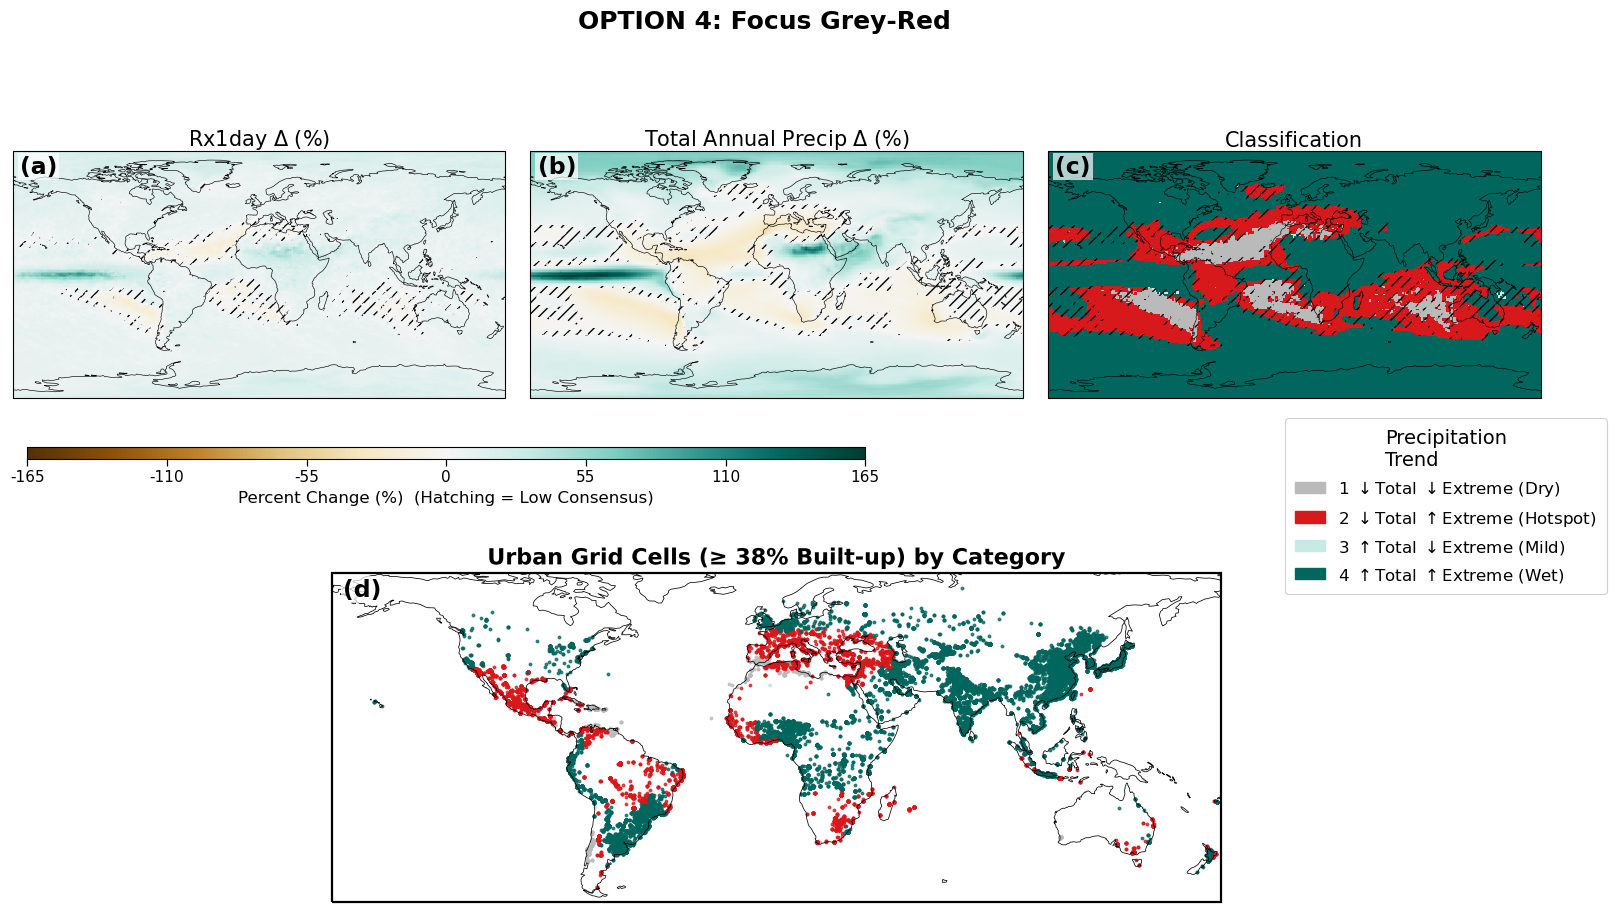


Finished displaying all options.


In [ ]:
# === View All 4 Color Options (Display Only - No Save) ===
# This script loops through 4 different color palettes and displays them using plt.show().

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import geopandas as gpd
import cartopy.crs as ccrs
from numpy import nan, where

# === Global Plot Settings ===
mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# Helper function for hatching
def add_hatching(ax, lon, lat, mask_bool):
    """Adds hatching to areas with low statistical consensus."""
    if mask_bool is not None and getattr(mask_bool, 'any', lambda: False)():
        ax.contourf(lon, lat, where(mask_bool, 1, nan), levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())

# === LOOP THROUGH ALL 4 OPTIONS ===
for COLOR_OPTION in [1, 2, 3, 4]:
    print(f"Displaying Figure Option {COLOR_OPTION}...")

    # 1. Define the Color Palette for the current loop iteration
    if COLOR_OPTION == 1:
        # Option 1: Scientific Muted (Recommended)
        intuitive_colors = ['#dfc27d', '#b2182b', '#92c5de', '#2166ac']
        desc = "Scientific Muted"
        
    elif COLOR_OPTION == 2:
        # Option 2: Soft Pastel
        intuitive_colors = ['#fdb863', '#e66101', '#b2abd2', '#5e3c99']
        desc = "Soft Pastel"

    elif COLOR_OPTION == 3:
        # Option 3: High Contrast Diverging
        intuitive_colors = ['#fc8d59', '#d73027', '#e0f3f8', '#4575b4']
        desc = "High Contrast"

    elif COLOR_OPTION == 4:
        # Option 4: Focus on Hotspot (Grey/Red)
        intuitive_colors = ['#bababa', '#d7191c', '#c7eae5', '#01665e']
        desc = "Focus Grey-Red"

    # Create Colormap
    class_cmap = ListedColormap(intuitive_colors)

    # 2. Setup Figure
    fig = plt.figure(figsize=(16, 9.5))
    
    # Add a super-title to identify the option on screen
    fig.suptitle(f"OPTION {COLOR_OPTION}: {desc}", fontsize=18, fontweight='bold', color='black')
    
    gs = GridSpec(2, 3, height_ratios=[14, 9], hspace=0.10, wspace=0.05)

    # Common settings for A and B
    cont_cmap = 'BrBG'
    combined_max = np.nanmax(np.abs([data_rx.min(), data_rx.max(), data_total.min(), data_total.max()]))
    nice_max = float(np.ceil(combined_max / 5) * 5)
    vmin, vmax = -nice_max, nice_max
    panel_letter_style = dict(fontsize=17, fontweight='bold')
    panel_box = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)

    # --- (a) Rx1day Delta ---
    ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    data_rx.plot(ax=ax_a, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_a.coastlines(resolution='110m', linewidth=0.45)
    add_hatching(ax_a, data_rx.lon, data_rx.lat, (consensus_rx < consensus_threshold))
    ax_a.set_title('Rx1day $\Delta$ (%)', pad=4)
    ax_a.text(0.015, 0.985, '(a)', transform=ax_a.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

    # --- (b) Total Annual Precip Delta ---
    ax_b = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    data_total.plot(ax=ax_b, transform=ccrs.PlateCarree(), cmap=cont_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_b.coastlines(resolution='110m', linewidth=0.45)
    add_hatching(ax_b, data_total.lon, data_total.lat, (consensus_total < consensus_threshold))
    ax_b.set_title('Total Annual Precip $\Delta$ (%)', pad=4)
    ax_b.text(0.015, 0.985, '(b)', transform=ax_b.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

    # Shared colorbar for A+B
    cax_ab = inset_axes(ax_b, width='100%', height='5.2%', loc='lower center',
                        bbox_to_anchor=(-1.02, -0.25, 1.70, 1), bbox_transform=ax_b.transAxes, borderpad=0)
    cb_norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cb = mpl.colorbar.ColorbarBase(cax_ab, cmap=plt.get_cmap(cont_cmap), norm=cb_norm, orientation='horizontal')
    cb_ticks = np.linspace(vmin, vmax, 7)
    cb.set_ticks(cb_ticks)
    cb.ax.set_xticklabels([f'{t:.0f}' for t in cb_ticks])
    cb.ax.tick_params(labelsize=11, length=5, width=0.9, pad=2)
    cb.set_label('Percent Change (%)  (Hatching = Low Consensus)', fontsize=12, labelpad=4)

    # --- (c) Classification (Using Current Loop Colors) ---
    ax_c = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
    classification.plot(ax=ax_c, transform=ccrs.PlateCarree(), cmap=class_cmap, add_colorbar=False)
    low_agree = (consensus_total < consensus_threshold) | (consensus_rx < consensus_threshold)
    add_hatching(ax_c, data_total.lon, data_total.lat, low_agree)
    ax_c.coastlines(resolution='110m', linewidth=0.45)
    ax_c.set_title('Classification', pad=4)
    ax_c.text(0.015, 0.985, '(c)', transform=ax_c.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

    # Legend for Classification
    class_labels = [
        Patch(color=class_cmap(0), label=r'1 $\downarrow$Total $\downarrow$Extreme (Dry)'),
        Patch(color=class_cmap(1), label=r'2 $\downarrow$Total $\uparrow$Extreme (Hotspot)'),
        Patch(color=class_cmap(2), label=r'3 $\uparrow$Total $\downarrow$Extreme (Mild)'),
        Patch(color=class_cmap(3), label=r'4 $\uparrow$Total $\uparrow$Extreme (Wet)')
    ]
    pos_c = ax_c.get_position(fig)
    legend_ax = fig.add_axes([pos_c.x1 - 0.08, pos_c.y0 - 0.2, 0.14, pos_c.height])
    legend_ax.axis('off')
    legend = legend_ax.legend(handles=class_labels, title='Precipitation\nTrend', loc='center left', frameon=True,
                              fontsize=12, title_fontsize=14, borderpad=0.6, labelspacing=0.55, handlelength=1.8)
    legend.get_frame().set_alpha(0.92)
    legend.get_frame().set_linewidth(0.8)

    # --- (d) Urban Grid Cells ---
    ax_d = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
    for spine in ax_d.spines.values():
        spine.set_linewidth(1.6)

    if 'urban_cmip6_join' in globals() and not urban_cmip6_join.empty:
        for cat in [1, 2, 3, 4]:
            sub = urban_cmip6_join[urban_cmip6_join['category'] == cat]
            if not sub.empty:
                gpd.GeoDataFrame(sub, geometry='geometry', crs='EPSG:4326').plot(
                    ax=ax_d, markersize=3.3, color=class_cmap(cat-1), alpha=0.75, transform=ccrs.PlateCarree())
    ax_d.coastlines(resolution='110m', linewidth=0.55)

    try:
        urban_threshold = int(threshold)
    except Exception:
        urban_threshold = 0

    title_d = ax_d.set_title(f'Urban Grid Cells (≥ {urban_threshold}% Built-up) by Category', fontsize=16, pad=6, fontweight='bold')
    import matplotlib.patheffects as patheffects
    title_d.set_path_effects([patheffects.withStroke(linewidth=3, foreground='white')])
    ax_d.text(0.012, 0.985, '(d)', transform=ax_d.transAxes, ha='left', va='top', **panel_letter_style, bbox=panel_box)

    plt.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.04)

    # 3. Display Only (No Save)
    plt.show()

print("\nFinished displaying all options.")

In [ ]:
print(ds_rx[var_rx].attrs)
print(ds_rx.attrs)

{'long_name': 'GDAL Band Number 1', 'grid_mapping': 'crs'}
{'Conventions': 'CF-1.5', 'Origin': 'NetCDF file created by loadeR.2nc: https://github.com/SantanderMetGroup/loadeR.2nc', 'R_package_desc': 'loadeR-v1.7.0', 'R_package_ref': 'https://doi.org/10.1016/j.envsoft.2018.09.009', 'R_package_URL': 'https://github.com/SantanderMetGroup/loadeR', 'updated_relanom': 'Done', 'GDAL': 'GDAL 1.11.4, released 2016/01/25', 'history': 'Wed May 28 08:15:32 2025: GDAL CreateCopy( /tmp/NETCDF___Rx1day_rel____180.0__90.00_180.00_90.000_360___180___1.000_1.000__configurat_1___1___144_____CRS_84_____LWFTtl9XwRo.tmp, ... )'}
